In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os
from google.colab import files
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


In [2]:
ellipse_data = pd.read_csv("/content/drive/MyDrive/ESL Passion Project/ELLIPSE_Final_github_train.csv")
ellipse_data2 = pd.read_csv("/content/drive/MyDrive/ESL Passion Project/ELLIPSE_Final_github_test.csv")


print(len(ellipse_data) + len(ellipse_data2) )

6482


In [3]:
df = pd.concat([ellipse_data,ellipse_data2],ignore_index=True)

df.head()

df.to_csv("/content/drive/MyDrive/ESL Passion Project/all_esl_essays.csv")

In [5]:
essays = df["full_text"]

In [6]:
essays = essays.tolist()
print(essays[:2])

['Imagine if you could prove other people that you are a good problem solver. Imagine that a problem is a good chance to do your best because youre a good problem solver, and you can learn something from that problem. I think that problems are a good chance to show people that youre good at something, and that they can seek your help if they need to. I agree that a problem is a good chance to do your best because you can learn from that problem, and prove yourself that you can do it.\n\nYou can learn from your problems, and that it enhances your skills. Learning from your problems can help enhance your techniques for problem solving. Learning from your problems can help you on other problems you might have on future occasions. Getting good at problem solving can lead you to helping other is they need the help from or they dont really know what to do. When you are good at problem solving and you seek to get better problem solving becomes easy for you because you have been doing it for a

In [7]:
all_text = "\n".join(essays)

chars = sorted(list(set(all_text)))



In [8]:
# char_to_idx: Maps each character to a number
char_to_index = {c: i for i,c in enumerate(chars)}

#idx_to_char: Reverse mapping (number back to character)
index_to_char = {i: c for i,c in enumerate(chars)}

vocab_size = len(chars)
print(vocab_size)

104


In [9]:
print(vocab_size)
print("Char to Index Dictionary")
print(char_to_index)
print("Index to Char Dictionary")
print(index_to_char)



104
Char to Index Dictionary
{'\n': 0, '\r': 1, ' ': 2, '!': 3, '"': 4, '#': 5, '$': 6, '%': 7, '&': 8, "'": 9, '(': 10, ')': 11, '*': 12, '+': 13, ',': 14, '-': 15, '.': 16, '/': 17, '0': 18, '1': 19, '2': 20, '3': 21, '4': 22, '5': 23, '6': 24, '7': 25, '8': 26, '9': 27, ':': 28, ';': 29, '<': 30, '=': 31, '>': 32, '?': 33, '@': 34, 'A': 35, 'B': 36, 'C': 37, 'D': 38, 'E': 39, 'F': 40, 'G': 41, 'H': 42, 'I': 43, 'J': 44, 'K': 45, 'L': 46, 'M': 47, 'N': 48, 'O': 49, 'P': 50, 'Q': 51, 'R': 52, 'S': 53, 'T': 54, 'U': 55, 'V': 56, 'W': 57, 'X': 58, 'Y': 59, 'Z': 60, '[': 61, '\\': 62, ']': 63, '_': 64, '`': 65, 'a': 66, 'b': 67, 'c': 68, 'd': 69, 'e': 70, 'f': 71, 'g': 72, 'h': 73, 'i': 74, 'j': 75, 'k': 76, 'l': 77, 'm': 78, 'n': 79, 'o': 80, 'p': 81, 'q': 82, 'r': 83, 's': 84, 't': 85, 'u': 86, 'v': 87, 'w': 88, 'x': 89, 'y': 90, 'z': 91, '{': 92, '|': 93, '}': 94, '~': 95, '\x80': 96, '\x82': 97, '\x9e': 98, 'º': 99, 'Â': 100, 'Ã': 101, 'Ê': 102, 'â': 103}
Index to Char Dictionary
{0:

In [10]:
#@title data is ALL of the text converted to encoded numeric form for the purpose of training -> numpy array format
data = np.array([char_to_index[ch] for ch in all_text])


sequence_length = 60

print(f"total characters in dataset: {len(data)}")


X = []
y = []

for i in range(len(data) - sequence_length):
  X.append(data[i:i+sequence_length])
  y.append(data[i + sequence_length])

X = np.array(X)
y = np.array(y)

#building train, val, test data
num_samples = len(X)
train_val_split = int(0.90*num_samples)
val_test_split = int(0.98*num_samples)


X_train = X[:train_val_split]
y_train = y[:train_val_split]

X_val = X[train_val_split:val_test_split]
y_val = y[train_val_split:val_test_split]

X_test = X[val_test_split:]
y_test = y[val_test_split:]





total characters in dataset: 15042208


In [22]:

#@title One-hot encode
class CharDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, vocab_size):
        self.X = X          # integer indices, shape (N, seq_len)
        self.y = y          # integer targets, shape (N,)
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seq = self.X[idx]                  # (seq_len,)
        one_hot = np.zeros((len(seq), self.vocab_size), dtype=np.float32)

        one_hot[np.arange(len(seq)), seq] = 1.0
        x_tensor = torch.from_numpy(one_hot)      # (seq_len, vocab_size)
        y_tensor = torch.tensor(self.y[idx]).long()
        return x_tensor, y_tensor



In [23]:
# @title building the LSTM


class CharRNN(nn.Module):
  def __init__(self, vocab_size, hidden_size=256,num_layers=2,dropout = 0.3):
    super(CharRNN, self).__init__()

    self.lstm = nn.LSTM(
        input_size=vocab_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first = True,
        dropout = dropout if num_layers > 1 else 0
        )

    self.fc = nn.Linear(hidden_size,vocab_size)


  def forward(self,x):
    lstm_out, (h,c) = self.lstm(x)

    last_output = lstm_out[:,-1,:]
    logits = self.fc(last_output)
    return logits


In [24]:
#@title Making our trained model generate text
def generate_text(my_model, starting_text, length=200,
                  sequence_length=60, temperature=1.0, device="cuda"):
    my_model.eval()
    encoded = [char_to_index.get(ch, 0) for ch in starting_text]

    if len(encoded) < sequence_length:
        encoded = [0] * (sequence_length - len(encoded)) + encoded
    encoded = encoded[-sequence_length:]

    generated = starting_text

    with torch.no_grad():
        for _ in range(length):
            x = np.zeros((1, sequence_length, vocab_size), dtype=np.float32)
            x[0, np.arange(sequence_length), encoded[-sequence_length:]] = 1.0
            x = torch.from_numpy(x).to(device)

            logits = my_model(x) / temperature
            probs = torch.softmax(logits, dim=1)
            next_idx = torch.multinomial(probs, 1).item()
            next_char = index_to_char[next_idx]

            generated += next_char
            encoded.append(next_idx)

    return generated


In [25]:
# @title Creating batches & loading them
batch_size = 256

train_dataset = CharDataset(X_train, y_train, vocab_size)
val_dataset   = CharDataset(X_val,   y_val,   vocab_size)
test_dataset  = CharDataset(X_test,  y_test,  vocab_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=512)


In [ ]:
# @title Training the Model and storing Train/Val Loss (DONE)


# define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(my_model.parameters(),lr=0.001)

num_epochs =10
starting_epoch=20

# Training
for epoch in range(num_epochs):

  my_model.train()
  train_loss=0

  for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    logits = my_model(X_batch)
    loss = criterion(logits,y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss+= loss.item()

  train_loss/= len(train_loader)
  train_losses.append(train_loss)


  my_model.eval()
  val_loss = 0

  with torch.no_grad():
    for X_batch, y_batch in val_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      logits = my_model(X_batch)
      loss = criterion(logits,y_batch)

      val_loss+= loss.item()

    val_loss/=len(val_loader)
    val_losses.append(val_loss)

  if (epoch + 1) % 5 == 0:
    torch.save(my_model.state_dict(), '/content/drive/MyDrive/ESL Passion Project/checkpoint_epoch_{}.pth'.format(epoch+1))
    print(f"Checkpoint saved at epoch {starting_epoch+epoch+1}")
    sample = generate_text(my_model, "The government is",
                           length=150,
                           sequence_length=sequence_length,
                           temperature=0.8,
                           device=device)
    print(sample[:300])



  print(f"Epoch {starting_epoch + epoch+1}/{starting_epoch + num_epochs} - Train Loss: {train_loss:.4f}, Val loss: {val_loss:.4f} ")




Epoch 21/30 - Train Loss: 0.9175, Val loss: 0.9037 
Epoch 22/30 - Train Loss: 0.9166, Val loss: 0.9019 
Epoch 23/30 - Train Loss: 0.9163, Val loss: 0.9025 
Epoch 24/30 - Train Loss: 0.9182, Val loss: 0.9041 
Checkpoint saved at epoch 25
The government isn't a great for people to have more time to do other activities. They can learn about subjects. For example, some students will not want to lose the o
Epoch 25/30 - Train Loss: 0.9193, Val loss: 0.9041 
Epoch 26/30 - Train Loss: 0.9201, Val loss: 0.9056 
Epoch 27/30 - Train Loss: 0.9196, Val loss: 0.9050 
Epoch 28/30 - Train Loss: 0.9207, Val loss: 0.9098 
Epoch 29/30 - Train Loss: 0.9303, Val loss: 0.9146 
Checkpoint saved at epoch 30
The government is when to grow at school with a group work, however, if we have a positive attitude is a chance for students to do not be all the person or someone tha
Epoch 30/30 - Train Loss: 0.9593, Val loss: 0.9339 


In [ ]:
#@title The model will start from these losses
print(f"Previous Train loss: {train_losses[-1]:.4f}")

print(f"Previous Validation loss: {(val_losses[-1]):.4f}")

Previous Train loss: 0.9183
Previous Validation loss: 0.9046


In [ ]:
print(f"Previous Train loss: {train_losses}")

print(f"Previous Validation loss: {val_losses}")

Previous Train loss: [1.191827827833258, 1.0259141290897686, 0.9942914704688772, 0.977409456506037, 0.9661796850468625, 0.9579836141954262, 0.9516230600764725, 0.9462322427997759, 0.9418346498188958, 0.9382635805747189, 0.9350328528964253, 0.9322710541103322, 0.9299456987833536, 0.9277023875113504, 0.9257865410739864, 0.924200384809767, 0.9225100706905955, 0.9210047700763405, 0.9195001637345261, 0.918294842862696, 0.9174975308052695, 0.9165573000553987, 0.9162544298974045, 0.9182239647043087, 0.9193458333331122, 0.9201092494306605, 0.9195743171694402, 0.9206564945239396, 0.9303033234284883, 0.9593084058370627]
Previous Validation loss: [1.022287151389986, 0.9792848169726653, 0.9598821365770065, 0.9470792401810227, 0.9378389522856349, 0.9335671374816495, 0.9286580608695685, 0.9255840218272532, 0.9214692554600858, 0.9189599207433056, 0.9163879278973058, 0.9146488436491904, 0.9136232958818906, 0.9104847152102968, 0.9090194066249863, 0.9102163210219885, 0.9066321071755585, 0.90493843937592

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]


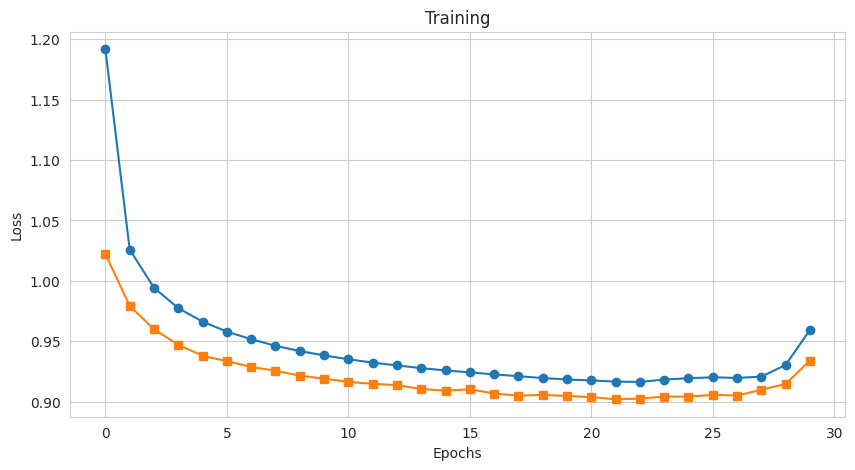

<Axes: >

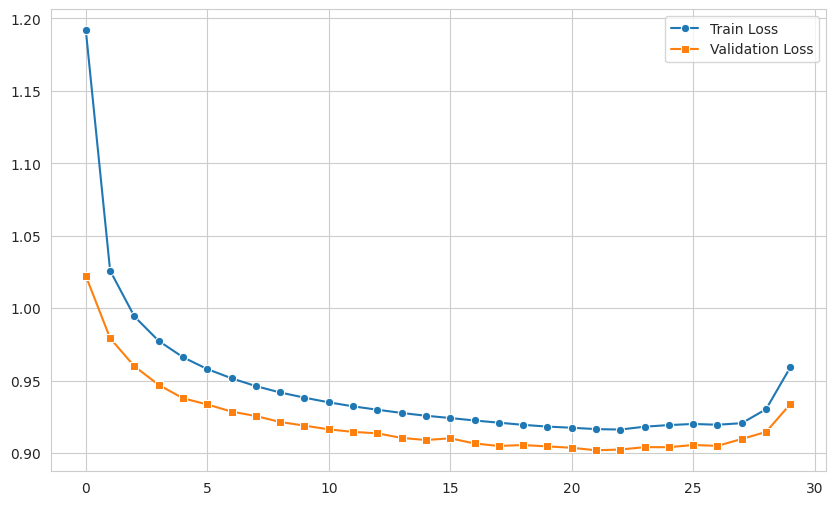

In [ ]:
# @title Plots (DONT TOUCH)
# plot training & validation loss

epochs=np.arange(30)
print(epochs)

plt.figure(figsize=(10,5))
plt.plot(epochs,train_losses,label='Train Loss', marker = 'o')
plt.plot(epochs,val_losses,label = 'Validation Loss',marker='s' )
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training")
plt.grid(True)
plt.show()


sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.lineplot(x=epochs,y=train_losses, label='Train Loss', marker = 'o')
sns.lineplot(x=epochs,y=val_losses,label = 'Validation Loss',marker='s' )


In [26]:
# @title Loading the Model Saved Parameters in (RERUN)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = CharRNN(vocab_size).to(device)
mid_model = CharRNN(vocab_size).to(device)

#best model is EPOCH 20
best_state_dict = torch.load("/content/drive/MyDrive/ESL Passion Project/checkpoint_epoch_5.pth")
best_model.load_state_dict(best_state_dict)

#mid model is EPOCH 15
mid_model_dict = torch.load("/content/drive/MyDrive/ESL Passion Project/checkpoint_epoch_15.pth")
mid_model.load_state_dict(mid_model_dict)

print("loaded model again")




loaded model again


In [ ]:
# @title Next Char Prediction Test Accuracy: best_model got 72.8% accuracy (NO need to run again)
#Accuracy: 63% initial, 72% after 30 epochs, (~73% accuracy) 72.8% after 20 epochs, 72.7% after 15 epochs, ~72% after 10 epochs

# X_test_tensor | y_test_tensor

best_model.eval()
all_preds = []

with torch.no_grad():
  for X_batch, y_batch in test_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)
    pred = best_model(X_batch)
    all_preds.append(pred)


all_preds = torch.cat(all_preds)
#argmax finds the index of the largest value from the predictions tensor
predictions = torch.argmax(all_preds,dim=1)

total_correct = (predictions == torch.tensor(y_test).to(device)).sum()
accuracy = total_correct.float() / len(y_test)
print("Test accuracy:", accuracy.item())


Test accuracy: 0.7285527586936951


Your mom is a career at school is that your body npw will others that they want. I would be hoact their linesation abrt. Ar is about the money bacioi ayshed on and should gate because if they can fot and Gsinyir


In [ ]:
#@title Testing it for fun against prompts (NO need to rerun)
prompts = [
    "Most schools let students",
    "I am",
    "Today is",
    "School",
    "Your mom"


]

for prompt in prompts:
    output = generate_text(best_model, prompt, length=150,
                           sequence_length=sequence_length,
                           temperature=0.8,
                           device=device)

    midput = generate_text(mid_model, prompt, length=150,
                           sequence_length=sequence_length,
                           temperature=0.8,
                           device=device)


    print("\n" + "="*70)
    print(f"Prompt: '{prompt}'")
    print("="*70)
    print("Best model: ",output)
    print("Mid model: ",midput)






Prompt: 'Most schools let students'
Best model:  Most schools let students understand more about what they are going to do. Students can even be discover what they want in the future and you can attend it.

You can accomplis
Mid model:  Most schools let students learn something they parents can work and they dont know what to do.

Schools should cause as Saln relining because you are so many of them that they

Prompt: 'I am'
Best model:  I am agree with the school should be praise to remember that people know what they are passing, but this program are better for them to prosted. Having th
Mid model:  I am my parents or simple capacity and works and being a say when they are. the teacher gave the students the amazing advantages that students have to do 

Prompt: 'Today is'
Best model:  Today is Marrise I like somthing in the future but i tried more praised enghanist and my mom, but I dont want to be a point, it will always preperent the posi
Mid model:  Today is a good version as well

In [ ]:
#train_losses, val_losses = [], []
print(train_losses)

[1.191827827833258, 1.0259141290897686, 0.9942914704688772, 0.977409456506037, 0.9661796850468625, 0.9579836141954262, 0.9516230600764725, 0.9462322427997759, 0.9418346498188958, 0.9382635805747189, 0.9350328528964253, 0.9322710541103322, 0.9299456987833536, 0.9277023875113504, 0.9257865410739864]


In [27]:
# @title Sampled 5 ESL prompts with 20 responses to each, total 100 (RERUN)
import random
esl_model = best_model

n_per_prompt = 20
rows = []

print(df["prompt"].value_counts()[:5])
print("-"*70)
prompts = ["Distance learning",
           "Success and failure",
           "Career commitment",
           "Being busy",
           "Impact of technology"]

for prompt in prompts:
  subset = df[df["prompt"]==prompt]

  sample = subset.sample(n=min(n_per_prompt,len(subset)),random_state=42)

  for _, row in sample.iterrows():
    rows.append({"prompt": prompt, "full_text": row["full_text"],"source": "human_esl"})

esl_real = pd.DataFrame(rows)
print(esl_real.head())
print(len(esl_real),"sampled essays")

esl_real.to_csv("/content/drive/MyDrive/ESL Passion Project/esl_real_sampled.csv",index=False)

prompt
Distance learning       489
Success and failure     379
Career commitment       367
Being busy              341
Impact of technology    301
Name: count, dtype: int64
----------------------------------------------------------------------
              prompt                                          full_text  \
0  Distance learning  Students who attend school online from home ha...   
1  Distance learning  Some people say that students are better off a...   
2  Distance learning  Some schools offer distance learning as an opt...   
3  Distance learning  I think that could be a good idea attend class...   
4  Distance learning  Distance school learning\n\nDisatance learning...   

      source  
0  human_esl  
1  human_esl  
2  human_esl  
3  human_esl  
4  human_esl  
100 sampled essays


In [28]:
# @title Builds Perplexity Score Function (RERUN)
first_essay_text = esl_real["full_text"].iloc[0]

from torch.nn.functional import log_softmax


def compute_complexity(text, model, char_to_index, vocab_size, sequence_length=60,device=device):
  indices = [char_to_index.get(ch,0) for ch in text]

  if len(indices) <= sequence_length:
    print(f"Warning: text too short ({len(indices)} chars)")
    return float("inf"), float("inf"),0

  total_nll = 0.0
  num_predictions = 0

  for t in range(sequence_length,len(indices)):
    context = indices[t-sequence_length:t]
    target = indices[t]

    x = np.zeros((1,sequence_length,vocab_size),dtype=np.float32)

    for i, index in enumerate(context):
      x[0,i,index] = 1.0

    x_tensor = torch.from_numpy(x).to(device)

    logits = model(x_tensor)

    log_probs = log_softmax(logits,dim=1)

    nll = -log_probs[0,target].item()
    total_nll += nll
    num_predictions +=1

  avg_nll = total_nll/num_predictions
  perplexity = np.exp(avg_nll)

  return perplexity, avg_nll, num_predictions



In [ ]:
#@title Practice perplexity on one essay (NO need to Run)
ppl, nll, n_chars = compute_complexity(
    first_essay_text,
    esl_model,
    char_to_index,
    vocab_size,
    sequence_length=60,
    device=device,
)

print("Perplexity:", ppl)
print("Avg NLL:", nll)
print("Num predictions:", n_chars)
print("Preview:", first_essay_text[:])


Perplexity: 2.4335253064099107
Avg NLL: 0.8893409494195119
Num predictions: 2222
Preview: Students who attend school online from home have possible advantages to complete work with time and can study easier. Another possible way that students can learn from home is having a good friend by your side and always telling you to not give up and pay attention to what the teacher is explaining to the class.

Disadvantages of online home school are the completion of the notes everyday to keep up with they topic the teacher is going with the class; you might get distracted with your phone or do something that is not paying attention to the teacher while they're explaining the topic of the day. And I really think that students should just go to normal school and learn the way everybody learns

Another dis-benefit attending classes from home is one , the student might not even pay attention or even write down the notes the teacher is going over with the class. They could get easily distracted by 

In [ ]:
esl_real.head()

,prompt,full_text,source,perplexity,avg_nll,num_chars_used
0,Distance learning,Students who attend school online from home ha...,human_esl,2.374315,0.864709,2222
1,Distance learning,Some people say that students are better off a...,human_esl,2.405594,0.877797,1788
2,Distance learning,Some schools offer distance learning as an opt...,human_esl,2.549709,0.935979,3664
3,Distance learning,I think that could be a good idea attend class...,human_esl,2.395094,0.873422,1220
4,Distance learning,Distance school learning\n\nDisatance learning...,human_esl,2.409793,0.879541,2413


In [ ]:
#@title Running Perplexity Score for our Natural ESL Data (No need to rerun)

# Perplexity is a measure of similarity in a way, we expect low perplexity between esl_model and ESL data since it's easily predictable.
# We expect high perplexity between esl_model and AI-generated writing, and mid perplexity for esl_model and native-ai writing

# low NLL -> confident, high NLL -> not confident

perplexities = []
avg_nll = []
num_chars_list = []

for idx, row in esl_real.iterrows():
  text = row["full_text"]

  p,n,l = compute_complexity(
      text,
      esl_model,
      char_to_index,
      vocab_size,
      60,
      device
  )

  perplexities.append(p)
  avg_nll.append(n)
  num_chars_list.append(l)

esl_real["perplexity"] = perplexities
esl_real["avg_nll"] = avg_nll
esl_real["num_chars_used"] = num_chars_list


In [ ]:
#title NO need to Rerun
print(esl_real[["prompt","perplexity"]])

print(esl_real["perplexity"].describe())


                  prompt  perplexity
0      Distance learning    2.374315
1      Distance learning    2.405594
2      Distance learning    2.549709
3      Distance learning    2.395094
4      Distance learning    2.409793
..                   ...         ...
95  Impact of technology    2.860432
96  Impact of technology    2.476376
97  Impact of technology    2.843510
98  Impact of technology    2.471605
99  Impact of technology    2.375197

[100 rows x 2 columns]
count    100.000000
mean       2.434400
std        0.361136
min        1.891634
25%        2.205389
50%        2.393020
75%        2.579523
max        4.259236
Name: perplexity, dtype: float64


In [29]:
#@title all 5 prompts (RERUN)
prompts_for_experiment = esl_real["prompt"].unique().tolist()

print(prompts_for_experiment)


# both ai prompts
native_ai_prompt = "Write a 400‑word persuasive essay responding to the following prompt as a fluent native English‑speaking high school student in an honors or AP class. Use richer vocabulary, more complex sentences (with subordinate clauses), and varied transitions, while staying clear and well‑organized, and generate only the essay itself: "
esl_ai_prompt = "Write a 400‑word persuasive essay responding to the following prompt as a mid‑level ESL high school student (roughly B1). Use everyday vocabulary, some repeated phrases, and mostly simple sentences. Include a few grammar and punctuation mistakes (for example with articles, prepositions, or verb tense), but keep the overall meaning clear, and generate only the essay itself: "

['Distance learning', 'Success and failure', 'Career commitment', 'Being busy', 'Impact of technology']


In [30]:
# @title This Handcrafts any prompts (RERUN)
def make_prompt(prompt_text, type):
  if type == "native":
    return (f"{native_ai_prompt} \n \n {prompt_text}")
  elif type == "esl":
    return (f"{esl_ai_prompt} \n \n {prompt_text}")
  else:
    raise ValueError("style must be 'native' or 'esl'")



In [31]:
#@title (RERUN) This Function Generates an AI essay by calling ChatGPT API (customizable for "native" or "esl")
import openai, time
from google.colab import userdata

api_key = userdata.get('openai_key')

client = openai.OpenAI(api_key=api_key)

# for i in range(len(prompts_for_experiments)):
#.   for n in range(20):
prompt1 = make_prompt(prompts_for_experiment[0],"native")
print(prompt1)

# function that generates AI essay w/ API call
def generate_essay(prompt,type,model,temperature=0.8):
  prompt_for_ai = make_prompt(prompt,type)

  messages = [
      {"role":"system", "content": "You are a helpful writing tutor who writes persuasive high school essays following the user’s instructions"},
      {"role":"user","content":prompt_for_ai}
  ]

  response = client.chat.completions.create(model=model,messages=messages,temperature=temperature)

  essay_text = response.choices[0].message.content

  return essay_text






Write a 400‑word persuasive essay responding to the following prompt as a fluent native English‑speaking high school student in an honors or AP class. Use richer vocabulary, more complex sentences (with subordinate clauses), and varied transitions, while staying clear and well‑organized, and generate only the essay itself:  
 
 Distance learning


In [ ]:
#@title Test: AI Generated Native Essay on "Distance Learning" Prompt (NO need to rerun )
native_ai_essay = generate_essay(prompt1,"native",model="gpt-4.1")

print(native_ai_essay)

**The Enduring Value of Distance Learning**

In an era where technological advancements have revolutionized nearly every aspect of daily life, education stands as one of the most profoundly transformed domains. While some critics may argue that traditional, in-person instruction remains the gold standard, I contend that distance learning not only meets but often surpasses the demands of modern education. The flexibility, accessibility, and wealth of resources provided by distance learning make it an indispensable tool that should be embraced rather than resisted.

To begin with, distance learning offers unparalleled flexibility for students and educators alike. Unlike the rigid schedules imposed by conventional schools, online learning platforms allow students to engage with material at their own pace and according to their unique circumstances. For instance, a student balancing part-time work or family responsibilities can tailor their study schedule to fit their needs, which often le

In [ ]:
#@title Test: AI Generated ESL on "Distance Learning" Prompt (NO need to rerun )
esl_ai_essay = generate_essay(prompt1,"esl",model="gpt-4.1")

print(len(esl_ai_essay.strip()))
print(esl_ai_essay.strip())

2052
**Prompt:** Distance learning

**Essay (mid-level ESL, B1):**

Distance learning is a way for students to study from home, usually using the computer and internet. In my opinion, distance learning is very helpful and should be used more in schools. There are some problems, but I think the good things are bigger.

First, distance learning is good because it gives students more time. When you stay at home, you do not need to travel to school. You can wake up later, and you do not feel tired from the bus or train. Also, you can use your time better. If you finish your work early, you can study more or do something you like, like reading a book or helping at home.

Second, distance learning makes learning easier for many students. Some students are shy to ask questions in class. But online, they can write their questions to the teacher in chat, so they feel more comfortable. Also, there are many videos and online books to help students. If you do not understand something, you can watc

In [ ]:
#@title Generating 100 AI-native and AI-esl essays and storing them in a csv (NO need to rerun)
'''
Feb 7- Today I made the function to generate an AI essay. Now, what's next? We need to generate native AISAs for all five prompts, 20 times, for a total of 100. Then, do that same thing for ESL and compute complexity scores or perplexity scores.
'''

number_of_essays_per_prompt = 20

ai_rows = []

for prompt in prompts_for_experiment:
  for i in range(number_of_essays_per_prompt):


    native_ai_essay = generate_essay(prompt, "native",model="gpt-4.1")
    esl_ai_essay = generate_essay(prompt, "esl",model="gpt-4.1")

    ai_rows.append({
        "prompt":prompt,
        "full_text": native_ai_essay,
        "style": "native_ai"
    })

    ai_rows.append({
        "prompt":prompt,
        "full_text": esl_ai_essay,
        "style": "esl_ai"
    })

ai_df = pd.DataFrame(ai_rows)
ai_df["id"] = range(len(ai_df))
print(ai_df["style"].value_counts())
print(len(ai_df))  # should be 200
ai_df.to_csv("/content/drive/MyDrive/ESL Passion Project/ai_essays_5prompts_20each.csv", index=False)



style
native_ai    100
esl_ai       100
Name: count, dtype: int64
200


In [ ]:
#@title (RERUN) This is a generalizable function that uses compute_complexity to add perplexity scores to a DF given the name of it's column that contains text
def add_perplexity(df,text_col,model):

  perplexities=[]
  avg_nlls = []
  num_chars_list=[]

  for text in df[text_col]:
    p,n,l = compute_complexity(text,model,char_to_index,vocab_size,60,device)

    perplexities.append(p)
    avg_nlls.append(n)
    num_chars_list.append(l)


  df = df.copy()
  df["perplexity"] = perplexities
  df["avg_nll"] = avg_nlls
  df["num_chars_used"] = num_chars_list
  return df

In [ ]:
print("HUMAN ESL:")
print(esl_real["perplexity"].describe())

print("\nAI by style:")
print(ai_scored.groupby("style")["perplexity"].describe())


HUMAN ESL:


KeyError: 'perplexity'

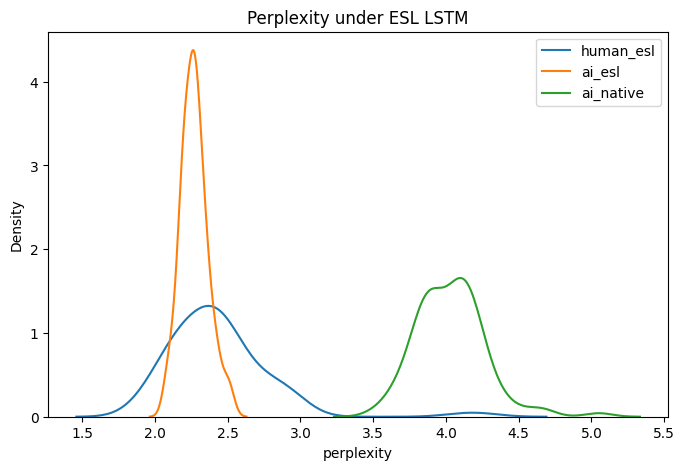

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(data=esl_real, x="perplexity", label="human_esl")
sns.kdeplot(data=ai_scored[ai_scored["style"]=="esl_ai"], x="perplexity", label="ai_esl")
sns.kdeplot(data=ai_scored[ai_scored["style"]=="native_ai"], x="perplexity", label="ai_native")
plt.legend()
plt.title("Perplexity under ESL LSTM")
plt.savefig("/content/drive/MyDrive/ESL Passion Project/perplexity_graph.png")
plt.show()


In [ ]:
#@title LSTM: Human vs. all AI (DO NOT RERUN)

import numpy as np

# Labels
y_human = np.zeros(len(esl_real))              # 0 = human ESL
y_ai    = np.ones(len(ai_scored))              # 1 = AI (both styles)

all_ppl = np.concatenate([
    esl_real["perplexity"].values,
    ai_scored["perplexity"].values
])
all_y = np.concatenate([y_human, y_ai])

# Sweep thresholds
thresholds = np.linspace(all_ppl.min(), all_ppl.max(), 200)

best_acc = 0.0
best_t = None

for t in thresholds:
    y_pred = (all_ppl > t).astype(int)         # > t → AI
    acc = (y_pred == all_y).mean()
    if acc > best_acc:
        best_acc = acc
        best_t = t

print("Best threshold (human vs ALL AI):", best_t)
print("Best overall accuracy:", best_acc)

# False positive rate on human ESL at this threshold
y_pred_human = (esl_real["perplexity"].values > best_t).astype(int)
fp_rate = (y_pred_human == 1).mean()
print("False positive rate on human ESL:", fp_rate)

# True positive rate on AI at this threshold
y_pred_ai = (ai_scored["perplexity"].values > best_t).astype(int)
tp_rate = (y_pred_ai == 1).mean()
print("True positive rate on AI:", tp_rate)


Best threshold (human vs ALL AI): 2.1455480198685954
Best overall accuracy: 0.7033333333333334
False positive rate on human ESL: 0.82
True positive rate on AI: 0.965


In [ ]:
#@title Human vs. AI native (DO NOT RERUN)
ai_native = ai_scored[ai_scored["style"] == "native_ai"].copy()

y_human2  = np.zeros(len(esl_real))
y_native  = np.ones(len(ai_native))

all_ppl2 = np.concatenate([
    esl_real["perplexity"].values,
    ai_native["perplexity"].values
])
all_y2 = np.concatenate([y_human2, y_native])

thresholds2 = np.linspace(all_ppl2.min(), all_ppl2.max(), 200)

best_acc2 = 0.0
best_t2 = None

for t in thresholds2:
    y_pred2 = (all_ppl2 > t).astype(int)
    acc2 = (y_pred2 == all_y2).mean()
    if acc2 > best_acc2:
        best_acc2 = acc2
        best_t2 = t

print("\nBest threshold (human vs AI-native):", best_t2)
print("Best overall accuracy:", best_acc2)

y_pred_human2 = (esl_real["perplexity"].values > best_t2).astype(int)
fp_rate2 = (y_pred_human2 == 1).mean()
print("False positive rate on human ESL:", fp_rate2)

y_pred_native = (ai_native["perplexity"].values > best_t2).astype(int)
tp_rate2 = (y_pred_native == 1).mean()
print("True positive rate on AI-native:", tp_rate2)



Best threshold (human vs AI-native): 3.002506796476543
Best overall accuracy: 0.99
False positive rate on human ESL: 0.02
True positive rate on AI-native: 1.0


In [ ]:
print("\nMean perplexity per group:")
print("Human ESL:", esl_real["perplexity"].mean())
print(ai_scored.groupby("style")["perplexity"].mean())



Mean perplexity per group:
Human ESL: 2.4343997421122294
style
esl_ai       2.270752
native_ai    4.033560
Name: perplexity, dtype: float64


In [32]:
#@title PHASE 2: LSTM project - Creating all_df (rerun?)


base = "/content/drive/MyDrive/ESL Passion Project/"

esl_real = pd.read_csv(f"{base}esl_real_sampled.csv")        # 100 human ESL
ai_raw   = pd.read_csv(f"{base}ai_essays_5prompts_20each.csv")
ai_scored = pd.read_csv(f"{base}ai_scored5prompts_20each.csv")  # has perplexity etc.

esl_real["group"] = "human_esl"
ai_scored["group"] = ai_scored["style"]   # "native_ai" or "esl_ai"

all_df = pd.concat([esl_real, ai_scored], ignore_index=True)


Calculating perplexity for human ESL essays... this might take a minute...
Calculation complete!


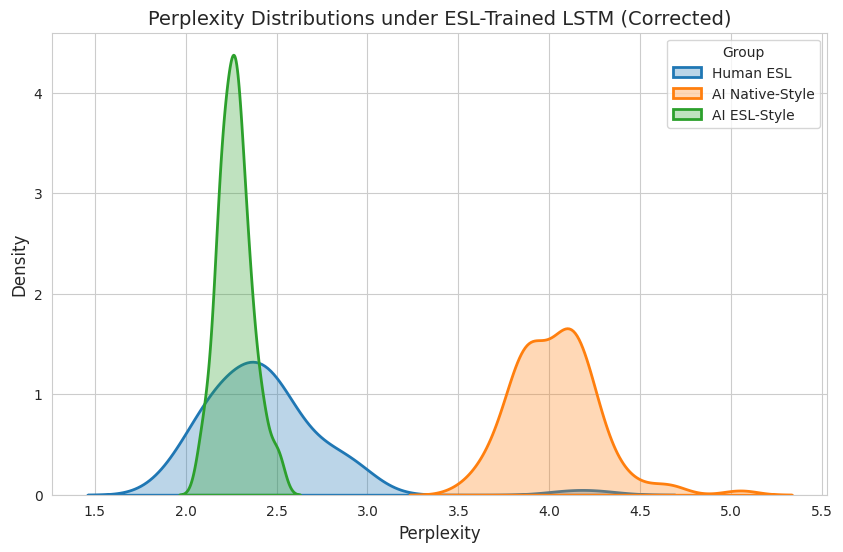


PERPLEXITY SUMMARY STATISTICS (CORRECTED)
           count      mean       std       min       25%       50%       75%  \
group                                                                          
esl_ai     100.0  2.270752  0.092342  2.075687  2.201008  2.263616  2.322070   
human_esl  100.0  2.434400  0.361136  1.891634  2.205389  2.393020  2.579523   
native_ai  100.0  4.033560  0.237468  3.514197  3.868453  4.042456  4.153501   

                max  
group                
esl_ai     2.518873  
human_esl  4.259236  
native_ai  5.049686  


In [ ]:
#@title Calculate perplexity for human ESL, then plot scores of all essay types (DO not rerun)
# --- FIX: Calculate Perplexity for Human ESL Rows ---

print("Calculating perplexity for human ESL essays... this might take a minute...")

# We only need to compute for rows where perplexity is NaN (which should be the human_esl ones)
# or just re-compute for the 'human_esl' group specifically.

# Let's iterate through the dataframe and fill in missing perplexities
# (Using a loop is safe and clear here)

# Ensure model is in eval mode
esl_model.eval()

for index, row in all_df.iterrows():
    if pd.isna(row['perplexity']) and row['group'] == 'human_esl':
        text = row['full_text']
        # Call your existing compute_complexity function
        ppl, nll, n_chars = compute_complexity(
            text,
            esl_model,
            char_to_index,
            vocab_size,
            sequence_length=60,
            device=device
        )
        # Update the dataframe
        all_df.at[index, 'perplexity'] = ppl
        all_df.at[index, 'avg_nll'] = nll
        all_df.at[index, 'num_chars_used'] = n_chars

print("Calculation complete!")

# --- NOW RE-RUN STEP 2 PLOTTING ---

# (Copy-pasting the plotting code again so you see the result immediately)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(data=all_df[all_df["group"]=="human_esl"], x="perplexity", label="Human ESL", fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=all_df[all_df["group"]=="native_ai"], x="perplexity", label="AI Native-Style", fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=all_df[all_df["group"]=="esl_ai"], x="perplexity", label="AI ESL-Style", fill=True, alpha=0.3, linewidth=2)

plt.title("Perplexity Distributions under ESL-Trained LSTM (Corrected)", fontsize=14)
plt.xlabel("Perplexity", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Group")
plt.show()

# Print summary stats again
print("\n" + "="*60)
print("PERPLEXITY SUMMARY STATISTICS (CORRECTED)")
print("="*60)
summary_stats = all_df.groupby("group")["perplexity"].describe()
print(summary_stats)



In [33]:
#@title Buidling a new model - DistilGPT2 (RERUN)

from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_id = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
gpt_model = GPT2LMHeadModel.from_pretrained(model_id).to(device)

def get_native_perplexity(text):

  inputs = tokenizer(text,return_tensors="pt",truncation=True).to(device)

  with torch.no_grad():

    outputs = gpt_model(**inputs,labels=inputs.input_ids)
    loss = outputs.loss

  return torch.exp(loss).item()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
#@title Scoring DistilGPT2 Perplexity (do NOT rerun)


# ppl is Perplexity score
native_ppl = []

for essay in all_df["full_text"]:

  try:
    ppl = get_native_perplexity(essay)
  except Exception as e:
    print(f"Error processing essay: {e}")
    score = float('nan') # Mark as NaN if it fails

  native_ppl.append(ppl)

all_df["native_ppl"] = native_ppl
print(all_df[['group', 'perplexity', 'native_ppl']].head())

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


       group  perplexity  native_ppl
0  human_esl    2.374315   49.944408
1  human_esl    2.405594   39.776901
2  human_esl    2.549709   24.992365
3  human_esl    2.395094   57.191418
4  human_esl    2.409793   53.579811


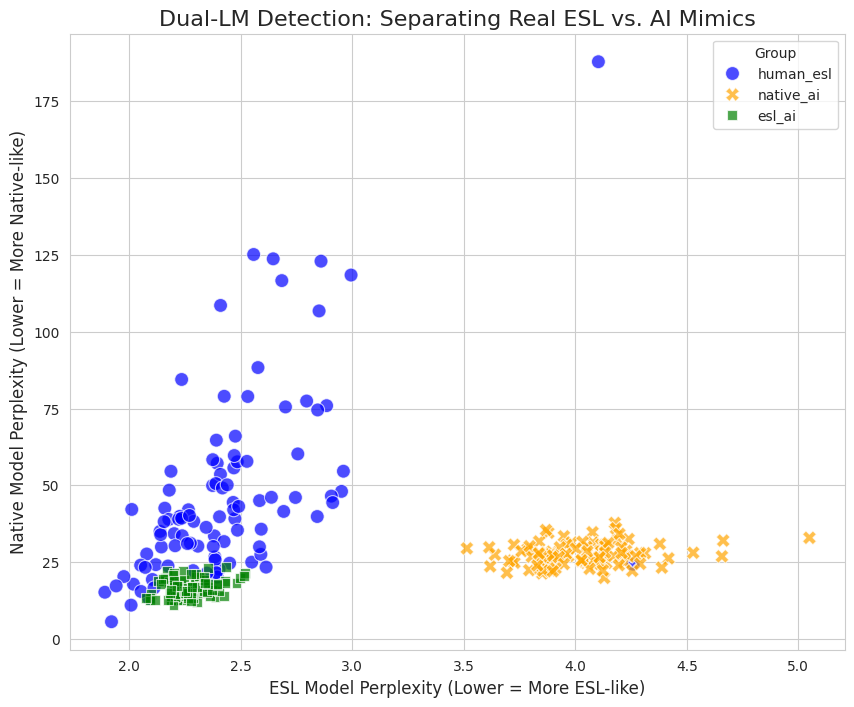


NATIVE PERPLEXITY SUMMARY STATISTICS
           count       mean        std        min        25%        50%  \
group                                                                     
esl_ai     100.0  16.460116   2.847843  10.872663  14.402817  15.710812   
human_esl  100.0  46.815788  29.933937   5.604332  27.319458  39.698812   
native_ai  100.0  27.493241   3.586287  19.869698  24.918451  27.111204   

                 75%         max  
group                             
esl_ai     18.756482   23.422934  
human_esl  54.869873  187.905579  
native_ai  29.824332   37.763943  


In [ ]:
# @title STEP 6: Visualize the Dual-LM Separation (The "ISEF Graph") ---
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))

# Scatter plot: X-axis = ESL Score, Y-axis = Native Score
# We use 'hue' and 'style' to distinguish the 3 groups
sns.scatterplot(
    data=all_df,
    x="perplexity",       # Judge 1: Your LSTM
    y="native_ppl",       # Judge 2: DistilGPT-2
    hue="group",          # Color by group
    style="group",        # Shape by group
    s=100,                # Size of dots
    alpha=0.7,            # Transparency
    palette={"human_esl": "blue", "native_ai": "orange", "esl_ai": "green"}
)

# Add titles and labels
plt.title("Dual-LM Detection: Separating Real ESL vs. AI Mimics", fontsize=16)
plt.xlabel("ESL Model Perplexity (Lower = More ESL-like)", fontsize=12)
plt.ylabel("Native Model Perplexity (Lower = More Native-like)", fontsize=12)
plt.legend(title="Group", fontsize=10)
plt.grid(True)

# Save the plot
plt.savefig("/content/drive/MyDrive/ESL Passion Project/dual_lm_separation.png", dpi=300)
plt.show()

# Print summary stats for the new Native Score
print("\n" + "="*60)
print("NATIVE PERPLEXITY SUMMARY STATISTICS")
print("="*60)
print(all_df.groupby("group")["native_ppl"].describe())


In [ ]:
e = all_df.to_csv(f"{base}all_df.csv")

In [ ]:
all_df.to_csv(f"{base}final_all_df.csv")

In [ ]:
# @title STEP 7: Train 2D Classifier and Report Final Results ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Prepare Data
# We want to distinguish Human ESL (Class 0) from ALL AI (Class 1)
# ... OR specifically Human ESL vs AI-ESL (the hard case). Let's do the hard case!

print("Task: Distinguish Human ESL vs. AI-ESL (The Hardest Case)")
subset = all_df[all_df["group"].isin(["human_esl", "esl_ai"])].copy()

X = subset[["perplexity", "native_ppl"]]  # The two features
y = (subset["group"] == "esl_ai").astype(int)  # 1 for AI, 0 for Human

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train 2D Classifier (Logistic Regression)
clf_2d = LogisticRegression()
clf_2d.fit(X_train, y_train)

# Evaluate
y_pred_2d = clf_2d.predict(X_test)
acc_2d = accuracy_score(y_test, y_pred_2d)

print(f"\n2D Classifier Accuracy (Dual-LM): {acc_2d:.2%}")

# 3. Compare with 1D Classifier (Old Method - Perplexity Only)
X_train_1d = X_train[["perplexity"]]
X_test_1d = X_test[["perplexity"]]

clf_1d = LogisticRegression()
clf_1d.fit(X_train_1d, y_train)

y_pred_1d = clf_1d.predict(X_test_1d)
acc_1d = accuracy_score(y_test, y_pred_1d)

print(f"1D Classifier Accuracy (ESL-Only): {acc_1d:.2%}")
print("-" * 40)
print(f"IMPROVEMENT: +{acc_2d - acc_1d:.2%} points")
print("-" * 40)

# Show detailed report for the 2D model
print("\nClassification Report (2D Model):")
print(classification_report(y_test, y_pred_2d, target_names=["Human ESL", "AI-ESL"]))


Task: Distinguish Human ESL vs. AI-ESL (The Hardest Case)

2D Classifier Accuracy (Dual-LM): 93.33%
1D Classifier Accuracy (ESL-Only): 75.00%
----------------------------------------
IMPROVEMENT: +18.33% points
----------------------------------------

Classification Report (2D Model):
              precision    recall  f1-score   support

   Human ESL       0.97      0.90      0.93        31
      AI-ESL       0.90      0.97      0.93        29

    accuracy                           0.93        60
   macro avg       0.93      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



Successfully loaded the master dataset!
Total rows: 300
Missing Perplexity values: 0


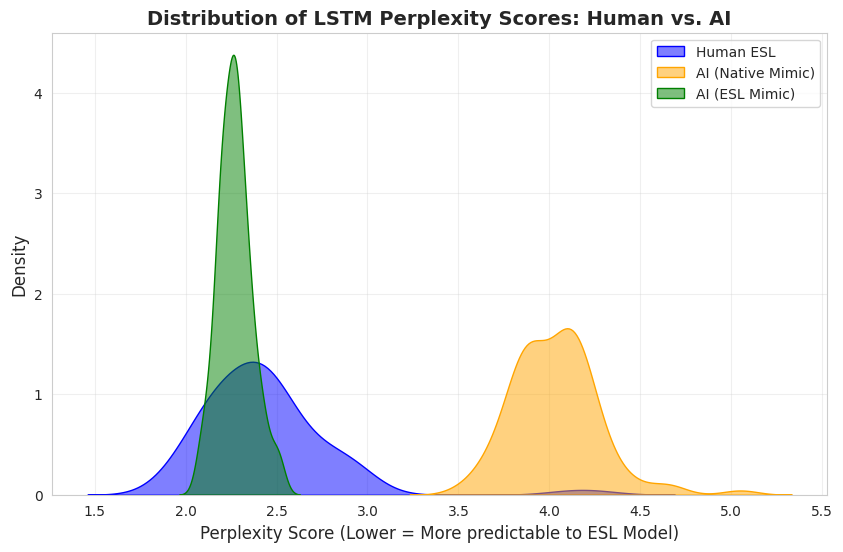

In [ ]:
#@title Phase 3- Analysis and Further Research

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Point directly to your saved Google Drive folder
BASE = "/content/drive/MyDrive/ESL Passion Project/"

# 2. Load the already completed, fully-scored dataset
# This bypasses the need to run ANY of the model/generation cells above!
try:
    alldf = pd.read_csv(f"{BASE}SUPER_final_dual_scores.csv")
    print("Successfully loaded the master dataset!")
except FileNotFoundError:
    print("File not found. Double check that the Drive is mounted and the path is correct.")

# 3. Quick sanity check to make sure the data isn't blank
print("Total rows:", len(alldf))
print("Missing Perplexity values:", alldf['perplexity'].isna().sum())

# 4. Generate the KDE Plot
plt.figure(figsize=(10, 6))

# Plot Human ESL
sns.kdeplot(data=alldf[alldf['group'] == 'human_esl']['perplexity'],
            label='Human ESL', fill=True, color='blue', alpha=0.5)

# Plot AI Native Mimic
sns.kdeplot(data=alldf[alldf['group'] == 'native_ai']['perplexity'],
            label='AI (Native Mimic)', fill=True, color='orange', alpha=0.5)

# Plot AI ESL Mimic
sns.kdeplot(data=alldf[alldf['group'] == 'esl_ai']['perplexity'],
            label='AI (ESL Mimic)', fill=True, color='green', alpha=0.5)

# Formatting the chart for your research paper/poster
plt.title('Distribution of LSTM Perplexity Scores: Human vs. AI', fontsize=14, fontweight='bold')
plt.xlabel('Perplexity Score (Lower = More predictable to ESL Model)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Save the plot directly to your Google Drive so you have it for your board
plt.savefig(f"{BASE}KDE_Perplexity_Distributions.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
alldf

,prompt,full_text,source,group,style,id,perplexity,avg_nll,num_chars_used,native_ppl
0,Distance learning,Students who attend school online from home ha...,human_esl,human_esl,NaN,NaN,2.374315,0.864709,2222.0,49.944408
1,Distance learning,Some people say that students are better off a...,human_esl,human_esl,NaN,NaN,2.405594,0.877797,1788.0,39.776901
2,Distance learning,Some schools offer distance learning as an opt...,human_esl,human_esl,NaN,NaN,2.549709,0.935979,3664.0,24.992365
3,Distance learning,I think that could be a good idea attend class...,human_esl,human_esl,NaN,NaN,2.395094,0.873422,1220.0,57.191418
4,Distance learning,Distance school learning\n\nDisatance learning...,human_esl,human_esl,NaN,NaN,2.409793,0.879541,2413.0,53.579811
...,...,...,...,...,...,...,...,...,...,...
295,Impact of technology,Technology is all around us. It make our lives...,NaN,esl_ai,esl_ai,195.0,2.341787,0.850914,1949.0,18.089939
296,Impact of technology,"In contemporary society, the impact of technol...",NaN,native_ai,native_ai,196.0,3.899603,1.360875,3091.0,22.035667
297,Impact of technology,Technology is changing our lives in many ways....,NaN,esl_ai,esl_ai,197.0,2.279227,0.823836,1780.0,21.119890
298,Impact of technology,The pervasive impact of technology on modern s...,NaN,native_ai,native_ai,198.0,4.195489,1.434010,2765.0,24.005939


Saved 3-panel figure successfully to: /content/drive/MyDrive/ESL Passion Project/ISEF_Timeline_Figure.png


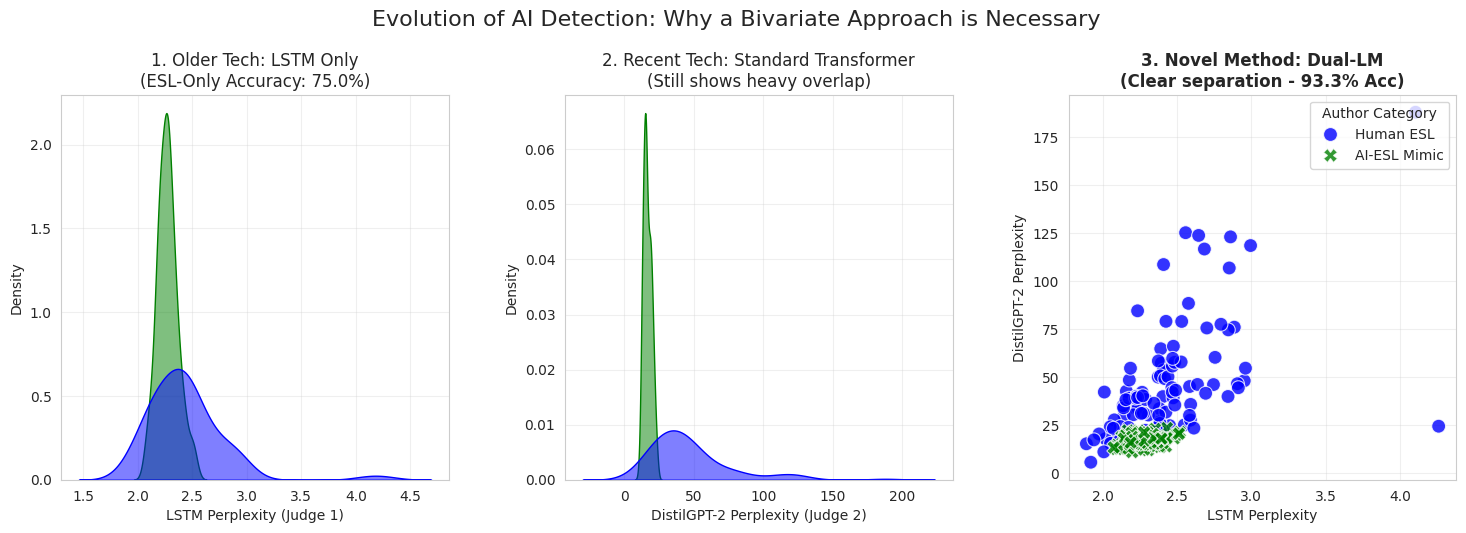

In [ ]:
# @title Generate 3-Panel Timeline Figure for ISEF Board
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for the "Hardest Case" (Human ESL vs AI-ESL) just like your Logistic Regression step
subset = alldf[alldf['group'].isin(['human_esl', 'esl_ai'])].copy()

# 2. Set up the matplotlib figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

# Use the exact same color scheme from your previous KDE plot
colors = {'human_esl': 'blue', 'esl_ai': 'green'}

# --- PANEL 1: "Back in Time" (LSTM Only) ---
sns.kdeplot(data=subset, x='perplexity', hue='group', fill=True, palette=colors, ax=axes[0], alpha=0.5, legend=False)
axes[0].set_title('1. Older Tech: LSTM Only\n(ESL-Only Accuracy: 75.0%)', fontsize=12)
axes[0].set_xlabel('LSTM Perplexity (Judge 1)')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

# --- PANEL 2: "Recent" (Transformer/DistilGPT-2 Only) ---
sns.kdeplot(data=subset, x='native_ppl', hue='group', fill=True, palette=colors, ax=axes[1], alpha=0.5, legend=False)
axes[1].set_title('2. Recent Tech: Standard Transformer\n(Still shows heavy overlap)', fontsize=12)
axes[1].set_xlabel('DistilGPT-2 Perplexity (Judge 2)')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

# --- PANEL 3: "Your Novel Method" (Dual-LM) ---
sns.scatterplot(data=subset, x='perplexity', y='native_ppl', hue='group', style='group',
                palette=colors, s=100, alpha=0.8, ax=axes[2])
axes[2].set_title('3. Novel Method: Dual-LM\n(Clear separation - 93.3% Acc)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('LSTM Perplexity')
axes[2].set_ylabel('DistilGPT-2 Perplexity')
axes[2].grid(True, alpha=0.3)

# Clean up legends for Panel 3
handles, labels = axes[2].get_legend_handles_labels()
# Map labels to prettier names for the board
label_map = {'human_esl': 'Human ESL', 'esl_ai': 'AI-ESL Mimic'}
pretty_labels = [label_map.get(l, l) for l in labels]
axes[2].legend(handles=handles, labels=pretty_labels, title='Author Category', loc='upper right')

# Main title
plt.suptitle('Evolution of AI Detection: Why a Bivariate Approach is Necessary', fontsize=16, y=1.05)

# 3. Save directly to your Drive!
save_path = f"{BASE}ISEF_Timeline_Figure.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved 3-panel figure successfully to: {save_path}")

plt.show()


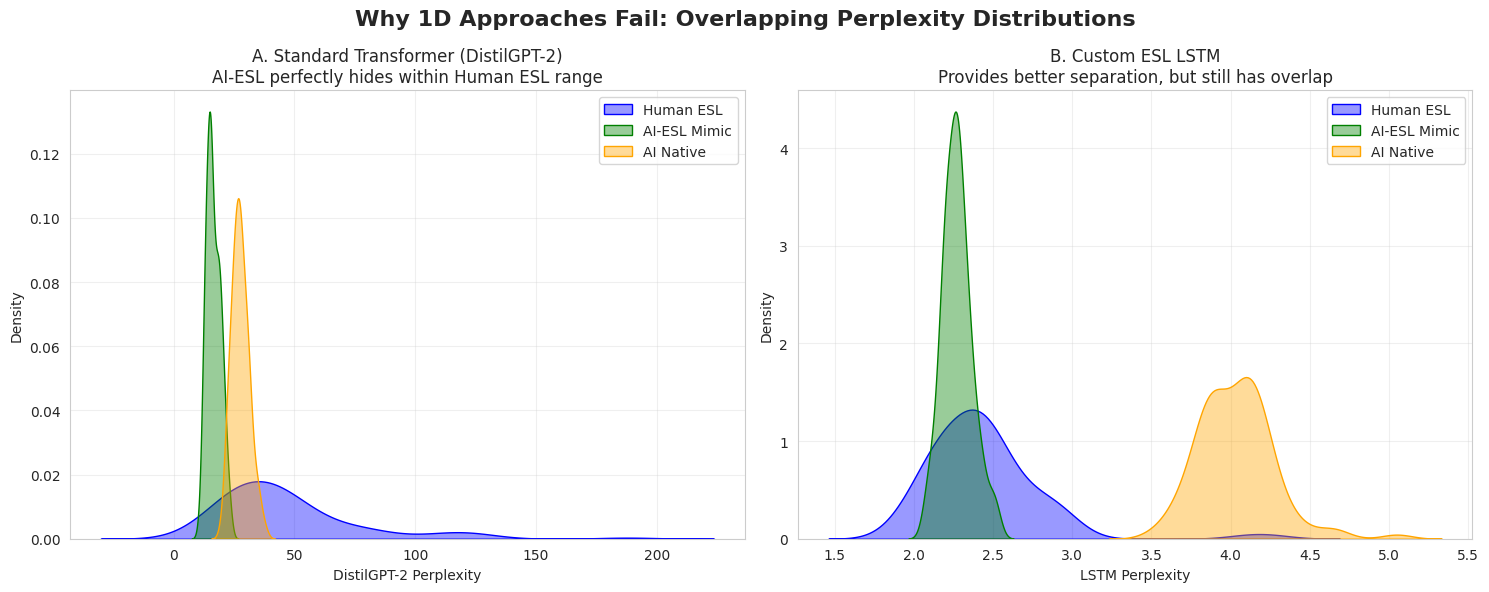

In [ ]:
# @title FIGURE 1: The Problem - 1D Feature Distributions
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {'human_esl': 'blue', 'esl_ai': 'green', 'native_ai': 'orange'}
labels = {'human_esl': 'Human ESL', 'esl_ai': 'AI-ESL Mimic', 'native_ai': 'AI Native'}

# Panel A: Standard Transformer (DistilGPT-2)
for group in colors.keys():
    sns.kdeplot(data=alldf[alldf['group'] == group], x='native_ppl',
                color=colors[group], label=labels[group], fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('A. Standard Transformer (DistilGPT-2)\nAI-ESL perfectly hides within Human ESL range', fontsize=12)
axes[0].set_xlabel('DistilGPT-2 Perplexity')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B: Custom ESL LSTM
for group in colors.keys():
    sns.kdeplot(data=alldf[alldf['group'] == group], x='perplexity',
                color=colors[group], label=labels[group], fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('B. Custom ESL LSTM\nProvides better separation, but still has overlap', fontsize=12)
axes[1].set_xlabel('LSTM Perplexity')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Why 1D Approaches Fail: Overlapping Perplexity Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}Figure1_Distributions.png", dpi=300)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


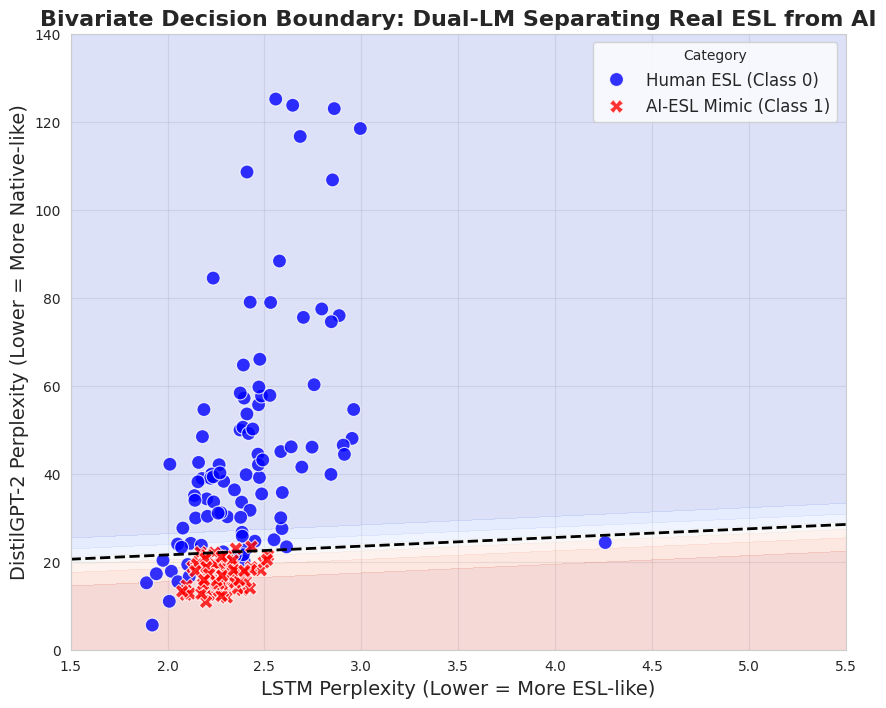

In [ ]:
# @title FIGURE 2 (CORRECTED): Bivariate Space with Decision Boundary
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# 1. Prepare data for the Hard Case
subset = alldf[alldf["group"].isin(["human_esl", "esl_ai"])].copy()
X = subset[["perplexity", "native_ppl"]]
y = (subset["group"] == "esl_ai").astype(int)

# 2. Train full 2D model for the boundary
clf_2d = LogisticRegression()
clf_2d.fit(X, y)

plt.figure(figsize=(10, 8))

# 3. Create a mesh grid tailored specifically to YOUR data's actual spread
# X-axis (LSTM Perplexity): Data ranges from ~1.8 to 5.2. We frame it 1.5 to 5.5
x_min, x_max = 1.5, 5.5
# Y-axis (Native Perplexity): Data ranges from ~10 to ~130 (ignoring the 185 outlier for the grid)
y_min, y_max = 0, 140

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Predict probabilities for the background shading
Z = clf_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# 4. Plot the contour background and the boundary line
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='dashed', linewidths=2)

# 5. Plot the actual scatter points on top
sns.scatterplot(data=subset, x='perplexity', y='native_ppl', hue='group', style='group',
                palette={'human_esl': 'blue', 'esl_ai': 'red'}, s=100, edgecolor='white', alpha=0.8)

# 6. Formatting to match your original plot perfectly
plt.title('Bivariate Decision Boundary: Dual-LM Separating Real ESL from AI', fontsize=16, fontweight='bold')
plt.xlabel('LSTM Perplexity (Lower = More ESL-like)', fontsize=14)
plt.ylabel('DistilGPT-2 Perplexity (Lower = More Native-like)', fontsize=14)

# Set the limits so it doesn't zoom out
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Clean up legend
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'human_esl': 'Human ESL (Class 0)', 'esl_ai': 'AI-ESL Mimic (Class 1)'}
pretty_labels = [label_map.get(l, l) for l in labels]
plt.legend(handles=handles, labels=pretty_labels, title='Category', loc='upper right', fontsize=12)

plt.grid(True, alpha=0.4)

# Save
save_path = f"{BASE}Figure2_Corrected_DecisionBoundary.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()


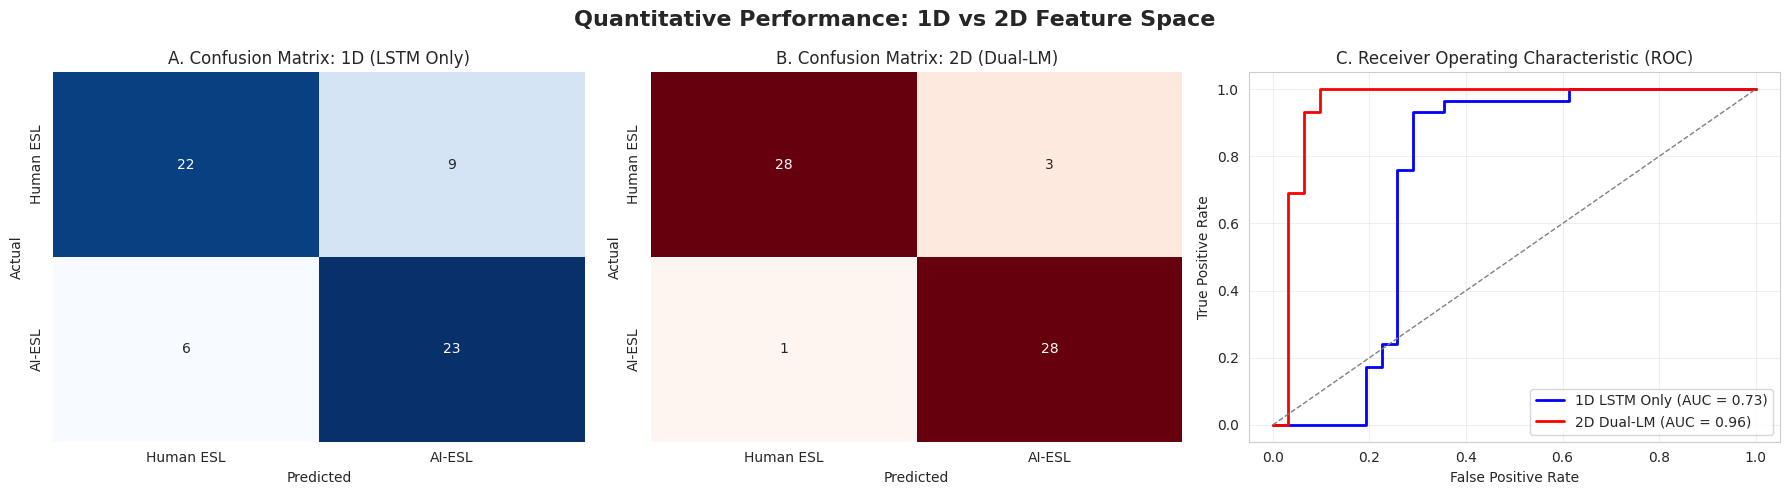

In [ ]:
# @title FIGURE 3: The Proof - Confusion Matrices & ROC Curves
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train 1D (LSTM only) and 2D (Dual)
clf_1d = LogisticRegression().fit(X_train[['perplexity']], y_train)
clf_2d = LogisticRegression().fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: 1D Confusion Matrix
cm_1d = confusion_matrix(y_test, clf_1d.predict(X_test[['perplexity']]))
sns.heatmap(cm_1d, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Human ESL', 'AI-ESL'], yticklabels=['Human ESL', 'AI-ESL'])
axes[0].set_title('A. Confusion Matrix: 1D (LSTM Only)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Panel B: 2D Confusion Matrix
cm_2d = confusion_matrix(y_test, clf_2d.predict(X_test))
sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False,
            xticklabels=['Human ESL', 'AI-ESL'], yticklabels=['Human ESL', 'AI-ESL'])
axes[1].set_title('B. Confusion Matrix: 2D (Dual-LM)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Panel C: ROC Curves
fpr_1d, tpr_1d, _ = roc_curve(y_test, clf_1d.predict_proba(X_test[['perplexity']])[:, 1])
roc_auc_1d = auc(fpr_1d, tpr_1d)

fpr_2d, tpr_2d, _ = roc_curve(y_test, clf_2d.predict_proba(X_test)[:, 1])
roc_auc_2d = auc(fpr_2d, tpr_2d)

axes[2].plot(fpr_1d, tpr_1d, color='blue', lw=2, label=f'1D LSTM Only (AUC = {roc_auc_1d:.2f})')
axes[2].plot(fpr_2d, tpr_2d, color='red', lw=2, label=f'2D Dual-LM (AUC = {roc_auc_2d:.2f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[2].set_title('C. Receiver Operating Characteristic (ROC)', fontsize=12)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc="lower right")
axes[2].grid(True, alpha=0.3)

plt.suptitle('Quantitative Performance: 1D vs 2D Feature Space', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}Figure3_ML_Metrics.png", dpi=300)
plt.show()


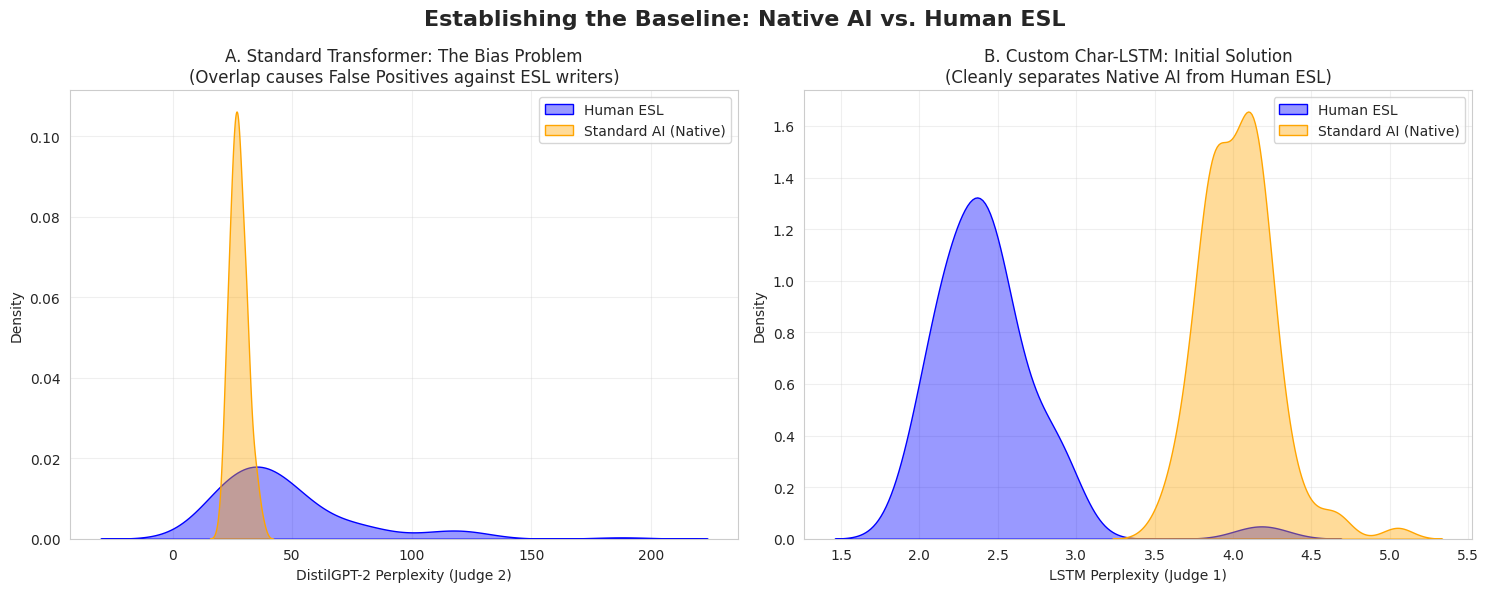

In [ ]:
# @title FIGURE 1 (INTRODUCTION): The Baseline & The Bias
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter ONLY for the baseline case: Human ESL vs Native AI
subset_base = alldf[alldf['group'].isin(['human_esl', 'native_ai'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_base = {'human_esl': 'blue', 'native_ai': 'orange'}
labels_base = {'human_esl': 'Human ESL', 'native_ai': 'Standard AI (Native)'}

# Panel A: The Bias in Standard Transformers
for group in colors_base.keys():
    sns.kdeplot(data=subset_base[subset_base['group'] == group], x='native_ppl',
                color=colors_base[group], label=labels_base[group], fill=True, alpha=0.4, ax=axes[0])

axes[0].set_title('A. Standard Transformer: The Bias Problem\n(Overlap causes False Positives against ESL writers)', fontsize=12)
axes[0].set_xlabel('DistilGPT-2 Perplexity (Judge 2)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B: Custom LSTM Separates Them
for group in colors_base.keys():
    sns.kdeplot(data=subset_base[subset_base['group'] == group], x='perplexity',
                color=colors_base[group], label=labels_base[group], fill=True, alpha=0.4, ax=axes[1])

axes[1].set_title('B. Custom Char-LSTM: Initial Solution\n(Cleanly separates Native AI from Human ESL)', fontsize=12)
axes[1].set_xlabel('LSTM Perplexity (Judge 1)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Establishing the Baseline: Native AI vs. Human ESL', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE}Figure1_Baseline_Bias.png", dpi=300)
plt.show()


Loading data from SUPER_final_dual_scores.csv...
Success! Found 200 rows for the Hard Case analysis.


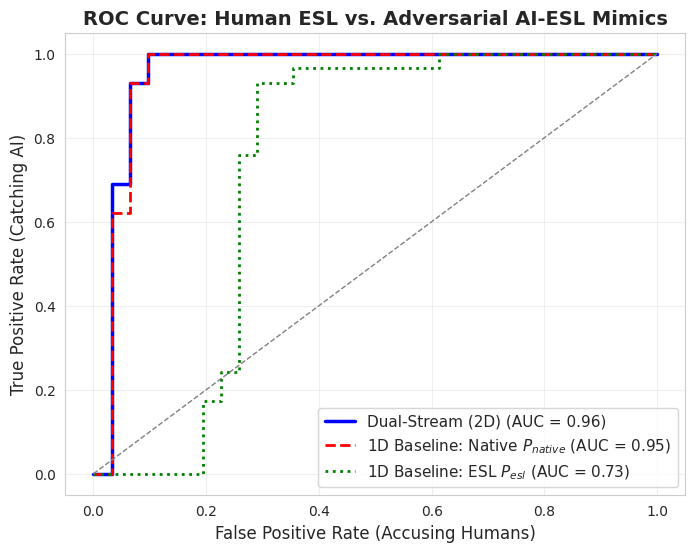

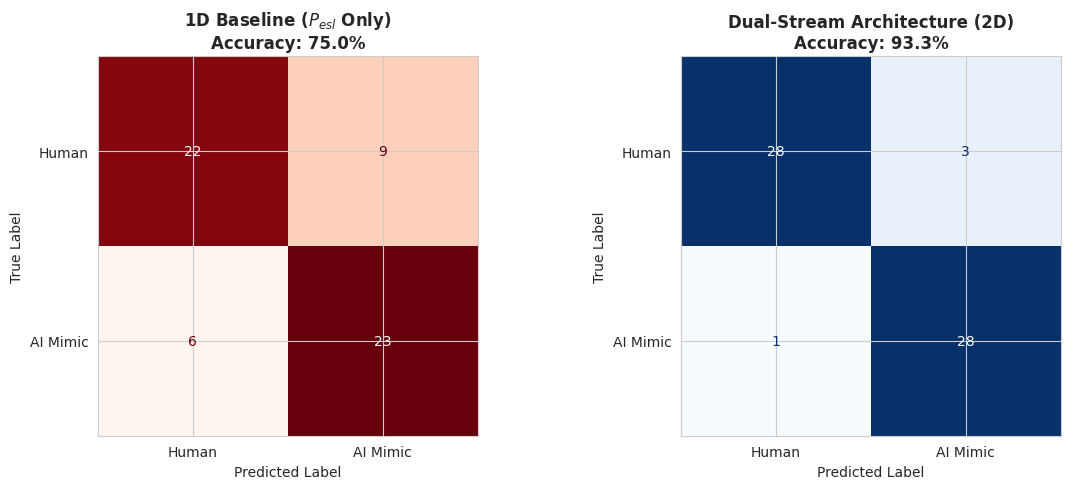

✅ Saved roc_curve.png and confusion_matrices.png to your Google Drive!


In [ ]:
# ==============================================================================
# PHASE 4: FINAL RESEARCH PAPER FIGURES (ROC CURVE & CONFUSION MATRICES)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd


# Ensure BASE is defined (adjust if your folder path is different)
BASE = '/content/drive/MyDrive/ESL Passion Project/'


# 1. Reload the guaranteed correct data to avoid any memory issues
print("Loading data from SUPER_final_dual_scores.csv...")
plot_df = pd.read_csv(f"{BASE}SUPER_final_dual_scores.csv")


# 2. Clean the group column just in case there are hidden spaces or weird formatting
plot_df['group'] = plot_df['group'].astype(str).str.strip().str.lower()


# 3. Standardize the names so we KNOW exactly what they are
plot_df['group'] = plot_df['group'].replace({
    'human_esl': 'humanesl',
    'esl_ai': 'eslai',
    'native_ai': 'nativeai'
})


# 4. Isolate the "Hard Case" dataset (Human ESL vs AI-ESL Mimic)
hard_case_df = plot_df[plot_df['group'].isin(['humanesl', 'eslai'])].copy()


# Double check that we actually have data before proceeding
if hard_case_df.empty:
    print("\nCRITICAL ERROR: Dataframe is still empty!")
    print("Here are the actual unique values in your 'group' column:")
    print(plot_df['group'].unique())
else:
    print(f"Success! Found {len(hard_case_df)} rows for the Hard Case analysis.")

    # Select the two perplexity columns using the exact correct name
    X_full = hard_case_df[['perplexity', 'native_ppl']]
    y_full = (hard_case_df['group'] == 'eslai').astype(int) # 1 for AI, 0 for Human


    # Split exact same way as your earlier tests (Test Size 0.3, Seed 42)
    X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

    # ---------------------------------------------------------
    # Train the 3 Models to Compare
    # ---------------------------------------------------------
    # A. Dual-Stream (2D) Classifier
    clf_2d = LogisticRegression()
    clf_2d.fit(X_train, y_train)
    y_prob_2d = clf_2d.predict_proba(X_test)[:, 1]
    y_pred_2d = clf_2d.predict(X_test)

    # B. 1D Baseline: Native Perplexity Only (Standard GPT Detector approach)
    # FIX: Changed 'nativeppl' to 'native_ppl' below
    clf_native = LogisticRegression()
    clf_native.fit(X_train[['native_ppl']], y_train)
    y_prob_native = clf_native.predict_proba(X_test[['native_ppl']])[:, 1]

    # C. 1D Baseline: ESL Perplexity Only (What gave the 75% in the paper)
    clf_esl = LogisticRegression()
    clf_esl.fit(X_train[['perplexity']], y_train)
    y_prob_esl = clf_esl.predict_proba(X_test[['perplexity']])[:, 1]
    y_pred_esl = clf_esl.predict(X_test[['perplexity']])

    # ---------------------------------------------------------
    # Figure A: ROC Curves
    # ---------------------------------------------------------
    fpr_2d, tpr_2d, _ = roc_curve(y_test, y_prob_2d)
    auc_2d = auc(fpr_2d, tpr_2d)

    fpr_native, tpr_native, _ = roc_curve(y_test, y_prob_native)
    auc_native = auc(fpr_native, tpr_native)

    fpr_esl, tpr_esl, _ = roc_curve(y_test, y_prob_esl)
    auc_esl = auc(fpr_esl, tpr_esl)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_2d, tpr_2d, color='blue', lw=2.5, label=f'Dual-Stream (2D) (AUC = {auc_2d:.2f})')
    plt.plot(fpr_native, tpr_native, color='red', lw=2, linestyle='--', label=f'1D Baseline: Native $P_{{native}}$ (AUC = {auc_native:.2f})')
    plt.plot(fpr_esl, tpr_esl, color='green', lw=2, linestyle=':', label=f'1D Baseline: ESL $P_{{esl}}$ (AUC = {auc_esl:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

    plt.xlabel('False Positive Rate (Accusing Humans)', fontsize=12)
    plt.ylabel('True Positive Rate (Catching AI)', fontsize=12)
    plt.title('ROC Curve: Human ESL vs. Adversarial AI-ESL Mimics', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)

    plt.savefig(f"{BASE}roc_curve.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Figure B: Side-by-Side Confusion Matrices
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm_1d = confusion_matrix(y_test, y_pred_esl)
    cm_2d = confusion_matrix(y_test, y_pred_2d)

    # Dynamically calculate accuracies for the titles
    acc_1d = accuracy_score(y_test, y_pred_esl) * 100
    acc_2d = accuracy_score(y_test, y_pred_2d) * 100

    # Plot 1D Baseline
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_1d, display_labels=['Human', 'AI Mimic'])
    disp1.plot(ax=axes[0], cmap='Reds', colorbar=False)
    axes[0].set_title(f'1D Baseline ($P_{{esl}}$ Only)\nAccuracy: {acc_1d:.1f}%', fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Plot 2D Dual-Stream
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_2d, display_labels=['Human', 'AI Mimic'])
    disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title(f'Dual-Stream Architecture (2D)\nAccuracy: {acc_2d:.1f}%', fontweight='bold')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.savefig(f"{BASE}confusion_matrices.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Saved roc_curve.png and confusion_matrices.png to your Google Drive!")


In [34]:
#@title Redefine BASE root

BASE = "/content/drive/MyDrive/ESL Passion Project/"


In [ ]:
# @title PHASE 3: The end: Generate 200 Gemini essays (100 native + 100 ESL mimic)

!pip install google-genai -q

from google import genai
from google.genai import types
import time
from google.colab import userdata

# Setup with new SDK
client_gemini = genai.Client(api_key=userdata.get('gemini_key'))

def generate_essay_gemini(prompt, style, temperature=0.8):
    prompt_for_ai = make_prompt(prompt, style)
    response = client_gemini.models.generate_content(
        model="gemini-2.5-flash",  # floating alias, works for all users
        contents=prompt_for_ai,
        config=types.GenerateContentConfig(temperature=temperature)
    )
    return response.text

# Generate 100 native + 100 ESL mimic
gemini_rows = []

for prompt in prompts_for_experiment:
    for i in range(20):
        try:
            native_essay = generate_essay_gemini(prompt, "native")
            gemini_rows.append({"prompt": prompt, "full_text": native_essay, "style": "native_ai", "model": "gemini-2.0-flash"})
            time.sleep(1)

            esl_essay = generate_essay_gemini(prompt, "esl")
            gemini_rows.append({"prompt": prompt, "full_text": esl_essay, "style": "esl_ai", "model": "gemini-2.0-flash"})
            time.sleep(1)

            print(f"✓ {prompt} — iteration {i+1}/20")

        except Exception as e:
            print(f"✗ Error on '{prompt}', iteration {i}: {e}")
            continue

gemini_df = pd.DataFrame(gemini_rows)
print(gemini_df["style"].value_counts())
print(f"Total essays generated: {len(gemini_df)}")
gemini_df.to_csv(f"{BASE}gemini_ai_essays.csv", index=False)
print("Saved to Drive ✓")



✓ Distance learning — iteration 1/20
✓ Distance learning — iteration 2/20
✓ Distance learning — iteration 3/20
✓ Distance learning — iteration 4/20
✓ Distance learning — iteration 5/20
✓ Distance learning — iteration 6/20
✓ Distance learning — iteration 7/20
✓ Distance learning — iteration 8/20
✓ Distance learning — iteration 9/20
✓ Distance learning — iteration 10/20
✓ Distance learning — iteration 11/20
✓ Distance learning — iteration 12/20
✓ Distance learning — iteration 13/20
✓ Distance learning — iteration 14/20
✓ Distance learning — iteration 15/20
✓ Distance learning — iteration 16/20
✓ Distance learning — iteration 17/20
✓ Distance learning — iteration 18/20
✓ Distance learning — iteration 19/20
✓ Distance learning — iteration 20/20
✓ Success and failure — iteration 1/20
✓ Success and failure — iteration 2/20
✓ Success and failure — iteration 3/20
✓ Success and failure — iteration 4/20
✓ Success and failure — iteration 5/20
✓ Success and failure — iteration 6/20
✓ Success and f

In [ ]:
#@title Part 3.2: Generate 200 Claude essays (100 native + 100 ESL mimic)
!pip install anthropic -q

import anthropic
import time
from google.colab import userdata

# Setup
claude_client = anthropic.Anthropic(api_key=userdata.get('claude_key'))

def generate_essay_claude(prompt, style, temperature=0.8):
    prompt_for_ai = make_prompt(prompt, style)
    message = claude_client.messages.create(
        model="claude-sonnet-4-5-20250929",
        max_tokens=1500,
        temperature=temperature,
        messages=[{"role": "user", "content": prompt_for_ai}]
    )
    return message.content[0].text

# Generate 100 native + 100 ESL mimic
claude_rows = []

for prompt in prompts_for_experiment:
    for i in range(20):
        try:
            native_essay = generate_essay_claude(prompt, "native")
            claude_rows.append({"prompt": prompt, "full_text": native_essay, "style": "native_ai","model": "claude-sonnet-4-5"})
            time.sleep(1)

            esl_essay = generate_essay_claude(prompt, "esl")
            claude_rows.append({"prompt": prompt, "full_text": esl_essay, "style": "esl_ai","model": "claude-sonnet-4-5"})
            time.sleep(1)

            print(f"✓ {prompt} — iteration {i+1}/20")

        except Exception as e:
            print(f"✗ Error on '{prompt}', iteration {i}: {e}")
            continue

claude_df = pd.DataFrame(claude_rows)
print(claude_df["style"].value_counts())
print(f"Total essays generated: {len(claude_df)}")
claude_df.to_csv(f"{BASE}claude_ai_essays.csv", index=False)
print("Saved to Drive ✓")


✓ Distance learning — iteration 1/20
✓ Distance learning — iteration 2/20
✓ Distance learning — iteration 3/20
✓ Distance learning — iteration 4/20
✓ Distance learning — iteration 5/20
✓ Distance learning — iteration 6/20
✓ Distance learning — iteration 7/20
✓ Distance learning — iteration 8/20
✓ Distance learning — iteration 9/20
✓ Distance learning — iteration 10/20
✓ Distance learning — iteration 11/20
✓ Distance learning — iteration 12/20
✓ Distance learning — iteration 13/20
✓ Distance learning — iteration 14/20
✓ Distance learning — iteration 15/20
✓ Distance learning — iteration 16/20
✓ Distance learning — iteration 17/20
✓ Distance learning — iteration 18/20
✓ Distance learning — iteration 19/20
✓ Distance learning — iteration 20/20
✓ Success and failure — iteration 1/20
✓ Success and failure — iteration 2/20
✓ Success and failure — iteration 3/20
✓ Success and failure — iteration 4/20
✓ Success and failure — iteration 5/20
✓ Success and failure — iteration 6/20
✓ Success and f

In [ ]:
BASE = "/content/drive/MyDrive/ESL Passion Project/"

#@title CELL C: Load and sample 200 COREFL essays
import pandas as pd

corefl = pd.read_csv(f"{BASE}main_COREFL.csv", sep="\t")

# Clean HTML tags that appear in some COREFL texts
corefl["Text"] = corefl["Text"].str.replace("<br/>", " ", regex=False).str.strip()

# Filter to written learner essays only
corefl_written = corefl[
    (corefl["Subcorpus"] == "Learners") &
    (corefl["Medium"] == "Written")
].copy()

# Drop rows where Text is empty or too short (under 150 chars — ensures real essays, not fragments)
corefl_written = corefl_written[corefl_written["Text"].str.len() > 150].copy()
corefl_written = corefl_written.dropna(subset=["Text"]).reset_index(drop=True)

print(f"Total written learner essays available: {len(corefl_written)}")
print(f"L1 breakdown:\n{corefl_written['L1'].value_counts()}")

# Safety check — make sure we have enough essays to sample 200
assert len(corefl_written) >= 200, f"Not enough essays! Only {len(corefl_written)} available."

# Sample 200 essays
corefl_sample = corefl_written.sample(n=200, random_state=42).reset_index(drop=True)

# Keep only what we need
corefl_sample = corefl_sample[["Text", "L1", "Proficiency"]].copy()
corefl_sample = corefl_sample.rename(columns={"Text": "full_text"})
corefl_sample["group"] = "human_esl"
corefl_sample["source"] = "COREFL"
corefl_sample["model"] = "human"

print(f"\nSampled {len(corefl_sample)} essays")
print(f"L1 breakdown in sample:\n{corefl_sample['L1'].value_counts()}")
print(f"Proficiency breakdown:\n{corefl_sample['Proficiency'].value_counts()}")
print(f"\nSample preview:")
print(corefl_sample["full_text"].iloc[0][:300])

corefl_sample.to_csv(f"{BASE}corefl_sampled.csv", index=False)
print("\nSaved to Drive ✓")


Total written learner essays available: 3256
L1 breakdown:
L1
Spanish     2392
Italian      288
German       279
Turkish       82
Chinese       80
Czech         78
Greek         40
Estonian      10
French         7
Name: count, dtype: int64

Sampled 200 essays
L1 breakdown in sample:
L1
Spanish    130
German      29
Italian     16
Chinese      8
Turkish      6
Czech        6
Greek        3
French       2
Name: count, dtype: int64
Proficiency breakdown:
Proficiency
B2 (upper intermediate)    50
C1 (lower advanced)        44
B1 (lower intermediate)    40
A2 (upper beginner)        31
A1 (lower beginner)        19
C2 (upper advanced)        16
Name: count, dtype: int64

Sample preview:
The last movie I saw was Big Hero Six. It is a Pixar movie that came out a few years ago already but that it is still a pure jem. The story is around a teenager named Hiro and his entering in a robotics university. He was motivated to get enroled in the uni by his brother, but he sadly died in a fir

Saved 

In [ ]:
#@title CELL D: Score COREFL + Gemini + Claude essays
import pandas as pd
import numpy as np
import torch

BASE = "/content/drive/MyDrive/ESL Passion Project/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Safety check — verify models are still in memory
try:
    best_model.eval()
    gpt_model.eval()
    print("✓ Models confirmed in memory")
except NameError:
  # Add inside the except NameError block after reloading best_model:
    chars = sorted(list(set("".join(pd.read_csv(f"{BASE}esl_real_sampled.csv")["full_text"].tolist()))))
    char_to_index = {c: i for i, c in enumerate(chars)}
    vocab_size = len(chars)

    print("⚠️ Models not in memory — reloading...")
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    model_id = "distilgpt2"
    tokenizer = GPT2Tokenizer.from_pretrained(model_id)
    gpt_model = GPT2LMHeadModel.from_pretrained(model_id).to(device)

    best_model = CharRNN(vocab_size).to(device)
    best_state_dict = torch.load(f"{BASE}checkpoint_epoch_5.pth")
    best_model.load_state_dict(best_state_dict)
    best_model.eval()
    print("✓ Models reloaded")

def score_df(df, label, text_col="full_text"):
    ppl_esl, ppl_native = [], []
    total = len(df)
    for i, text in enumerate(df[text_col]):
        try:
            p_esl, _, _ = compute_complexity(text, best_model, char_to_index, vocab_size, 60, device)
            p_nat = get_native_perplexity(str(text))
        except Exception as e:
            print(f"  ⚠️ Error on row {i}: {e}")
            p_esl, p_nat = float("nan"), float("nan")
        ppl_esl.append(p_esl)
        ppl_native.append(p_nat)
        if (i + 1) % 20 == 0:
            print(f"  [{label}] Scored {i+1}/{total}")
    df = df.copy()
    df["perplexity"] = ppl_esl
    df["native_ppl"] = ppl_native
    return df

# Load all three
corefl_sample = pd.read_csv(f"{BASE}corefl_sampled.csv")
gemini_df     = pd.read_csv(f"{BASE}gemini_ai_essays.csv")
claude_df     = pd.read_csv(f"{BASE}claude_ai_essays.csv")

print(f"Scoring COREFL ({len(corefl_sample)} essays)...")
corefl_scored = score_df(corefl_sample, "COREFL")
corefl_scored.to_csv(f"{BASE}corefl_scored.csv", index=False)
print("✓ COREFL scored and saved")

print(f"\nScoring Gemini ({len(gemini_df)} essays)...")
gemini_scored = score_df(gemini_df, "Gemini")
gemini_scored.to_csv(f"{BASE}gemini_ai_scored.csv", index=False)
print("✓ Gemini scored and saved")

print(f"\nScoring Claude ({len(claude_df)} essays)...")
claude_scored = score_df(claude_df, "Claude")
claude_scored.to_csv(f"{BASE}claude_ai_scored.csv", index=False)
print("✓ Claude scored and saved")

print("\n✅ All scoring complete.")


✓ Models confirmed in memory
Scoring COREFL (200 essays)...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  [COREFL] Scored 20/200
  [COREFL] Scored 40/200
  [COREFL] Scored 60/200
  [COREFL] Scored 80/200
  [COREFL] Scored 100/200
  [COREFL] Scored 120/200
  [COREFL] Scored 140/200
  [COREFL] Scored 160/200
  [COREFL] Scored 180/200
  [COREFL] Scored 200/200
✓ COREFL scored and saved

Scoring Gemini (200 essays)...
  [Gemini] Scored 20/200
  [Gemini] Scored 40/200
  [Gemini] Scored 60/200
  [Gemini] Scored 80/200
  [Gemini] Scored 100/200
  [Gemini] Scored 120/200
  [Gemini] Scored 140/200
  [Gemini] Scored 160/200
  [Gemini] Scored 180/200
  [Gemini] Scored 200/200
✓ Gemini scored and saved

Scoring Claude (200 essays)...
  [Claude] Scored 20/200
  [Claude] Scored 40/200
  [Claude] Scored 60/200
  [Claude] Scored 80/200
  [Claude] Scored 100/200
  [Claude] Scored 120/200
  [Claude] Scored 140/200
  [Claude] Scored 160/200
  [Claude] Scored 180/200
  [Claude] Scored 200/200
✓ Claude scored and saved

✅ All scoring complete.


In [ ]:
#@title CELL E: Rebuild master dataset (~900 essays)
import pandas as pd

BASE = "/content/drive/MyDrive/ESL Passion Project/"

existing      = pd.read_csv(f"{BASE}SUPER_final_dual_scores.csv")
corefl_scored = pd.read_csv(f"{BASE}corefl_scored.csv")
gemini_scored = pd.read_csv(f"{BASE}gemini_ai_scored.csv")
claude_scored = pd.read_csv(f"{BASE}claude_ai_scored.csv")

# Map 'style' → 'group' for AI dataframes
gemini_scored["group"] = gemini_scored["style"]
claude_scored["group"] = claude_scored["style"]

# Standardize — keep only these 4 columns from each
keep = ["full_text", "group", "perplexity", "native_ppl"]

def safe_select(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing} in df with columns: {list(df.columns)}")
    return df[cols].copy()

existing_clean = safe_select(existing, keep)
corefl_clean   = safe_select(corefl_scored, keep)
gemini_clean   = safe_select(gemini_scored, keep)
claude_clean   = safe_select(claude_scored, keep)

master = pd.concat([existing_clean, corefl_clean, gemini_clean, claude_clean], ignore_index=True)

# Normalize group labels
master["group"] = master["group"].str.strip().str.lower()

# Drop any rows with NaN scores
before = len(master)
master = master.dropna(subset=["perplexity", "native_ppl"]).reset_index(drop=True)
after = len(master)
print(f"Dropped {before - after} rows with NaN scores")

print("\nGroup counts:")
print(master["group"].value_counts())
print(f"\nTotal essays: {len(master)}")

master.to_csv(f"{BASE}MASTER_final_scores.csv", index=False)
print("\n✅ Saved MASTER_final_scores.csv")


Dropped 0 rows with NaN scores

Group counts:
group
human_esl    300
native_ai    300
esl_ai       300
Name: count, dtype: int64

Total essays: 900

✅ Saved MASTER_final_scores.csv


Group counts:
group
human_esl    300
native_ai    300
esl_ai       300
Name: count, dtype: int64
  Fold 1: Acc=0.942  FPR=0.067
  Fold 2: Acc=0.933  FPR=0.117
  Fold 3: Acc=0.958  FPR=0.050
  Fold 4: Acc=0.942  FPR=0.117
  Fold 5: Acc=0.950  FPR=0.067

5-Fold CV Accuracy : 0.945 ± 0.008
5-Fold CV FPR      : 0.083 ± 0.028
Bootstrap 95% CI   : (0.922, 0.960)


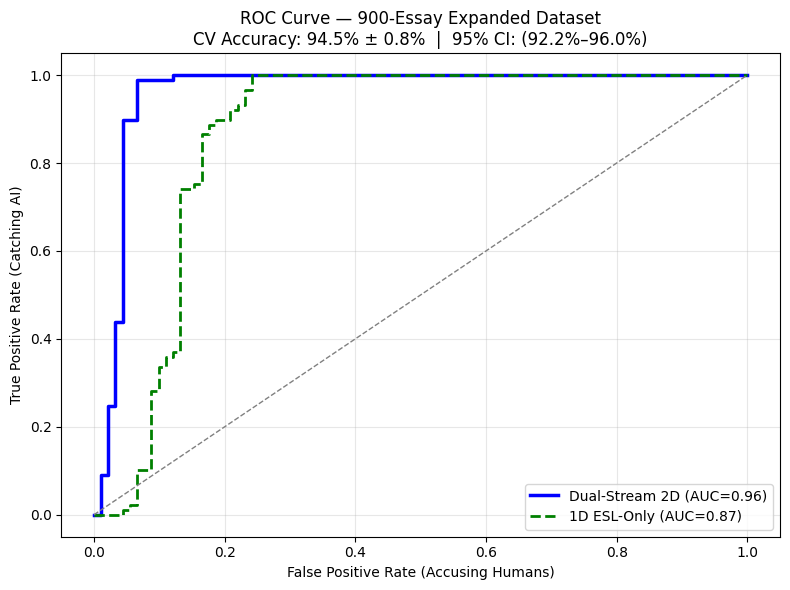

✓ ROC saved


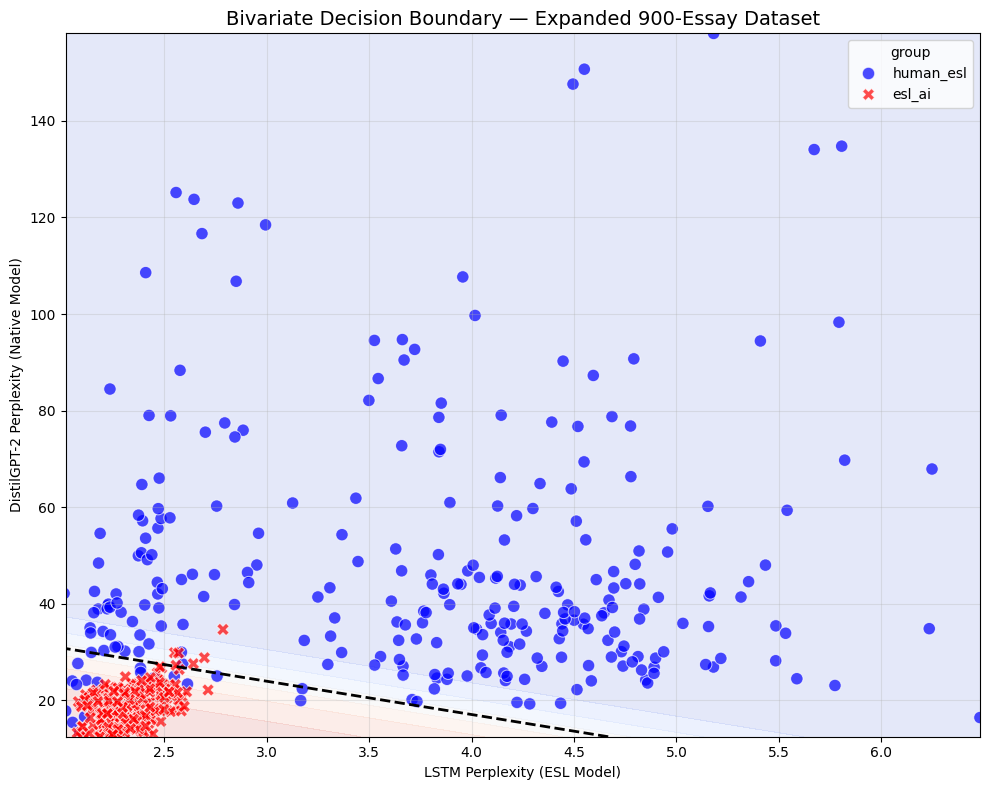

✓ Decision boundary saved


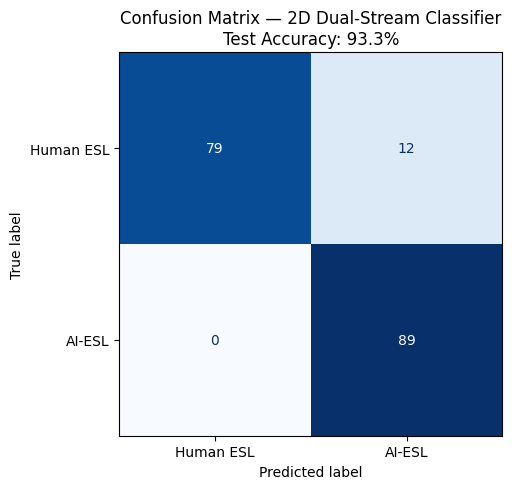

✓ Confusion matrix saved

✅ ALL DONE. Final numbers:
   CV Accuracy : 94.5% ± 0.8%
   95% CI      : 92.2% – 96.0%
   CV FPR      : 8.3%
   ROC-AUC     : 0.962


In [ ]:
#@title CELL F: Cross-validation + Bootstrap CIs + Figures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

BASE = "/content/drive/MyDrive/ESL Passion Project/"
master = pd.read_csv(f"{BASE}MASTER_final_scores.csv")
master = master.dropna(subset=["perplexity", "native_ppl"])

print("Group counts:")
print(master["group"].value_counts())

# Hard case only: Human ESL vs AI-ESL mimic
subset = master[master["group"].isin(["human_esl", "esl_ai"])].copy()
X = subset[["perplexity", "native_ppl"]].values
y = (subset["group"] == "esl_ai").astype(int).values

# --- 5-Fold Stratified Cross-Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accs, cv_fprs = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X[train_idx], y[train_idx])
    y_pred = clf.predict(X[test_idx])
    acc = accuracy_score(y[test_idx], y_pred)
    fpr = (y_pred[y[test_idx] == 0] == 1).mean()
    cv_accs.append(acc)
    cv_fprs.append(fpr)
    print(f"  Fold {fold+1}: Acc={acc:.3f}  FPR={fpr:.3f}")

mean_acc = np.mean(cv_accs)
std_acc  = np.std(cv_accs)
mean_fpr = np.mean(cv_fprs)
print(f"\n5-Fold CV Accuracy : {mean_acc:.3f} ± {std_acc:.3f}")
print(f"5-Fold CV FPR      : {mean_fpr:.3f} ± {np.std(cv_fprs):.3f}")

# --- Bootstrap 95% CI ---
rng = np.random.default_rng(42)
boot_accs = []
for _ in range(1000):
    idx = rng.integers(0, len(X), len(X))
    b = LogisticRegression(max_iter=1000).fit(X[idx], y[idx])
    boot_accs.append(accuracy_score(y[idx], b.predict(X[idx])))

ci_low  = np.percentile(boot_accs, 2.5)
ci_high = np.percentile(boot_accs, 97.5)
print(f"Bootstrap 95% CI   : ({ci_low:.3f}, {ci_high:.3f})")

# --- Final train/test for figures ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf_2d  = LogisticRegression(max_iter=1000).fit(X_train, y_train)
clf_1d  = LogisticRegression(max_iter=1000).fit(X_train[:, [0]], y_train)

y_pred_2d   = clf_2d.predict(X_test)
y_prob_2d   = clf_2d.predict_proba(X_test)[:, 1]
y_prob_1d   = clf_1d.predict_proba(X_test[:, [0]])[:, 1]

# --- Figure 1: ROC Curve ---
fpr_2d, tpr_2d, _ = roc_curve(y_test, y_prob_2d)
fpr_1d, tpr_1d, _ = roc_curve(y_test, y_prob_1d)
auc_2d = auc(fpr_2d, tpr_2d)
auc_1d = auc(fpr_1d, tpr_1d)

plt.figure(figsize=(8, 6))
plt.plot(fpr_2d, tpr_2d, color="blue",  lw=2.5, label=f"Dual-Stream 2D (AUC={auc_2d:.2f})")
plt.plot(fpr_1d, tpr_1d, color="green", lw=2, linestyle="--", label=f"1D ESL-Only (AUC={auc_1d:.2f})")
plt.plot([0,1],[0,1], color="gray", lw=1, linestyle="--")
plt.title(f"ROC Curve — 900-Essay Expanded Dataset\nCV Accuracy: {mean_acc:.1%} ± {std_acc:.1%}  |  95% CI: ({ci_low:.1%}–{ci_high:.1%})", fontsize=12)
plt.xlabel("False Positive Rate (Accusing Humans)")
plt.ylabel("True Positive Rate (Catching AI)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}MASTER_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ ROC saved")

# --- Figure 2: Decision Boundary ---
colors = {"human_esl": "blue", "esl_ai": "red"}
x_min = subset["perplexity"].quantile(0.01)
x_max = subset["perplexity"].quantile(0.99)
y_min = subset["native_ppl"].quantile(0.01)
y_max = subset["native_ppl"].quantile(0.99)

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = clf_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.15, cmap="coolwarm")
plt.contour(xx, yy, Z, levels=[0.5], colors="black", linestyles="dashed", linewidths=2)
sns.scatterplot(data=subset, x="perplexity", y="native_ppl",
                hue="group", style="group",
                palette=colors, s=80, alpha=0.7, edgecolor="white")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Bivariate Decision Boundary — Expanded 900-Essay Dataset", fontsize=14)
plt.xlabel("LSTM Perplexity (ESL Model)")
plt.ylabel("DistilGPT-2 Perplexity (Native Model)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}MASTER_decision_boundary.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Decision boundary saved")

# --- Figure 3: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_2d)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human ESL", "AI-ESL"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — 2D Dual-Stream Classifier\nTest Accuracy: {accuracy_score(y_test, y_pred_2d):.1%}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE}MASTER_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Confusion matrix saved")

print(f"\n✅ ALL DONE. Final numbers:")
print(f"   CV Accuracy : {mean_acc:.1%} ± {std_acc:.1%}")
print(f"   95% CI      : {ci_low:.1%} – {ci_high:.1%}")
print(f"   CV FPR      : {mean_fpr:.1%}")
print(f"   ROC-AUC     : {auc_2d:.3f}")


In [ ]:
#@title CELL G: Per-model accuracy breakdown
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

BASE = "/content/drive/MyDrive/ESL Passion Project/"

# Load master for classifier — already clean and complete
master = pd.read_csv(f"{BASE}MASTER_final_scores.csv")
master = master.dropna(subset=["perplexity", "native_ppl"])

print("Master group counts:")
print(master["group"].value_counts())

# Train classifier on full dataset
subset    = master[master["group"].isin(["human_esl", "esl_ai"])].copy()
X_all     = subset[["perplexity", "native_ppl"]].values
y_all     = (subset["group"] == "esl_ai").astype(int).values
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print(f"\nOverall test accuracy: {accuracy_score(y_te, clf.predict(X_te)):.1%}")

# Load individual scored files just for model_source tagging
gemini_scored = pd.read_csv(f"{BASE}gemini_ai_scored.csv")
claude_scored = pd.read_csv(f"{BASE}claude_ai_scored.csv")
existing      = pd.read_csv(f"{BASE}SUPER_final_dual_scores.csv")

gemini_scored["model_source"] = "gemini-2.5-flash"
claude_scored["model_source"] = "claude-4-5-sonnet"
existing["model_source"]      = "gpt-4.1"

gemini_scored["group"] = gemini_scored["style"]
claude_scored["group"] = claude_scored["style"]

keep = ["full_text", "group", "perplexity", "native_ppl", "model_source"]

def safe_select(df, cols):
    for c in cols:
        if c not in df.columns:
            df[c] = "unknown"
    return df[cols].copy()

ai_only = pd.concat([
    safe_select(existing[existing["group"] == "esl_ai"],      keep),
    safe_select(gemini_scored[gemini_scored["group"] == "esl_ai"], keep),
    safe_select(claude_scored[claude_scored["group"] == "esl_ai"], keep),
], ignore_index=True).dropna(subset=["perplexity", "native_ppl"])

human_all = master[master["group"] == "human_esl"].copy()

print("\n" + "="*55)
print("PER-MODEL ACCURACY (AI-ESL vs Human ESL)")
print("="*55)

for model_name in ["gpt-4.1", "gemini-2.5-flash", "claude-3-5-sonnet"]:
    model_esl = ai_only[ai_only["model_source"] == model_name]
    if len(model_esl) == 0:
        print(f"  {model_name}: no data found")
        continue
    n = min(len(model_esl), len(human_all))
    test_set = pd.concat([human_all.sample(n, random_state=42), model_esl], ignore_index=True)
    X_m = test_set[["perplexity", "native_ppl"]].values
    y_m = (test_set["group"] == "esl_ai").astype(int).values
    acc = accuracy_score(y_m, clf.predict(X_m))
    fpr = (clf.predict(X_m[y_m == 0]) == 1).mean()
    print(f"  {model_name:<25} Acc={acc:.1%}  FPR={fpr:.1%}  (n={len(model_esl)} essays)")

print("="*55)


Master group counts:
group
human_esl    300
native_ai    300
esl_ai       300
Name: count, dtype: int64

Overall test accuracy: 93.3%

PER-MODEL ACCURACY (AI-ESL vs Human ESL)
  gpt-4.1                   Acc=96.0%  FPR=8.0%  (n=100 essays)
  gemini-2.5-flash          Acc=93.5%  FPR=8.0%  (n=100 essays)
  claude-3-5-sonnet         Acc=95.5%  FPR=8.0%  (n=100 essays)


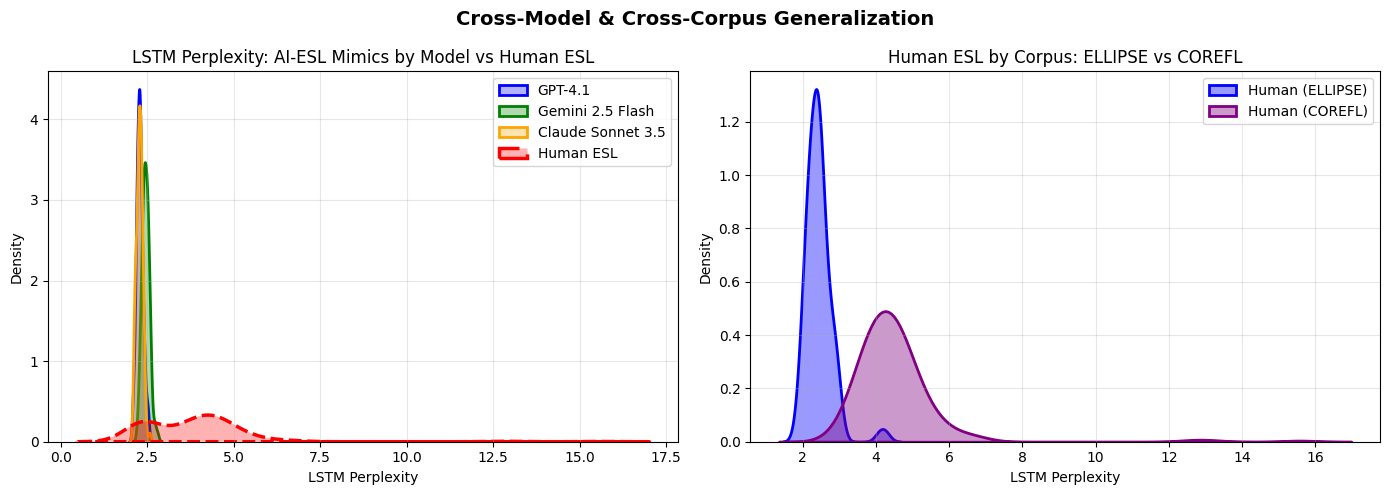

✓ Per-model KDE saved


In [ ]:
#@title CELL H: Per-model KDE plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = "/content/drive/MyDrive/ESL Passion Project/"

# Load individual files only for model_source tagging
existing      = pd.read_csv(f"{BASE}SUPER_final_dual_scores.csv")
gemini_scored = pd.read_csv(f"{BASE}gemini_ai_scored.csv")
claude_scored = pd.read_csv(f"{BASE}claude_ai_scored.csv")
corefl_scored = pd.read_csv(f"{BASE}corefl_scored.csv")

existing["model_source"] = "GPT-4.1"
existing.loc[existing["group"] == "human_esl", "model_source"] = "Human (ELLIPSE)"
gemini_scored["model_source"] = "Gemini 2.5 Flash"
claude_scored["model_source"] = "Claude Sonnet 3.5"
corefl_scored["model_source"] = "Human (COREFL)"

gemini_scored["group"] = gemini_scored["style"]
claude_scored["group"] = claude_scored["style"]

keep = ["full_text", "group", "perplexity", "native_ppl", "model_source"]

def safe_select(df, cols):
    for c in cols:
        if c not in df.columns:
            df[c] = "unknown"
    return df[cols].copy()

tagged = pd.concat([
    safe_select(existing,      keep),
    safe_select(gemini_scored, keep),
    safe_select(claude_scored, keep),
    safe_select(corefl_scored, keep),
], ignore_index=True).dropna(subset=["perplexity", "native_ppl"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: AI-ESL mimics by model vs Human ESL
esl_ai = tagged[tagged["group"] == "esl_ai"]
for model_name, color in [("GPT-4.1","blue"), ("Gemini 2.5 Flash","green"), ("Claude Sonnet 3.5","orange")]:
    data = esl_ai[esl_ai["model_source"] == model_name]["perplexity"].dropna()
    if len(data) > 5:
        sns.kdeplot(data=data, label=model_name, color=color,
                    fill=True, alpha=0.3, linewidth=2, ax=axes[0])

human_data = tagged[tagged["group"] == "human_esl"]["perplexity"].dropna()
sns.kdeplot(data=human_data, label="Human ESL", color="red",
            fill=True, alpha=0.3, linewidth=2.5, linestyle="--", ax=axes[0])

axes[0].set_title("LSTM Perplexity: AI-ESL Mimics by Model vs Human ESL", fontsize=12)
axes[0].set_xlabel("LSTM Perplexity")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Human ESL by corpus
human_all = tagged[tagged["group"] == "human_esl"]
for source, color in [("Human (ELLIPSE)","blue"), ("Human (COREFL)","purple")]:
    data = human_all[human_all["model_source"] == source]["perplexity"].dropna()
    if len(data) > 5:
        sns.kdeplot(data=data, label=source, color=color,
                    fill=True, alpha=0.4, linewidth=2, ax=axes[1])

axes[1].set_title("Human ESL by Corpus: ELLIPSE vs COREFL", fontsize=12)
axes[1].set_xlabel("LSTM Perplexity")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Cross-Model & Cross-Corpus Generalization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE}MASTER_per_model_kde.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Per-model KDE saved")


In [42]:
import os
os.remove("/content/drive/MyDrive/ESL Passion Project/toefl_checkpoint.csv")
print("Deleted.")


Deleted.


In [43]:
#@title PHASE 5: TOEFL Validation

# ============================================================
# PHASE 3: TOEFL11 Generalization Experiment
# ============================================================
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression

BASE        = "/content/drive/MyDrive/ESL Passion Project/"
TOEFL_BASE  = "/content/drive/MyDrive/ESL Passion Project/TOEFL/data/text/"
CKPT_PATH   = BASE + "toefl_checkpoint.csv"
FINAL_PATH  = BASE + "toefl_results_final.csv"

# ── STEP 1: Load index + stratified sample ───────────────────
index_df = pd.read_csv(TOEFL_BASE + "index.csv", header=None,
                       names=["filename","prompt","language","score_level"])
print(f"Total TOEFL essays in index: {len(index_df)}")

N_PER_CELL = 10
sampled = []
for lang in index_df["language"].unique():
    for level in ["low","medium","high"]:
        cell = index_df[(index_df["language"]==lang) & (index_df["score_level"]==level)]
        n = min(N_PER_CELL, len(cell))
        if n > 0:
            sampled.append(cell.sample(n=n, random_state=42))

sample_df = pd.concat(sampled, ignore_index=True)
print(f"Stratified sample: {len(sample_df)} essays across {sample_df['language'].nunique()} languages")
print(sample_df.groupby(["language","score_level"]).size().unstack(fill_value=0))

# ── STEP 2: Score essays (with checkpoint resume) ────────────
if os.path.exists(CKPT_PATH) and os.path.getsize(CKPT_PATH) > 0:
    ckpt_df = pd.read_csv(CKPT_PATH)
    already_done = set(ckpt_df["filename"].tolist())
    print(f"\nResuming from checkpoint: {len(ckpt_df)} already scored")
else:
    ckpt_df = pd.DataFrame()
    already_done = set()


results = []
errors  = []

for i, row in sample_df.iterrows():
    fname = row["filename"]
    if fname in already_done:
        continue

    essay_path = TOEFL_BASE + f"responses/original/{fname}"
    try:
        with open(essay_path, "r", encoding="utf-8", errors="replace") as f:
            text = f.read().strip()
        if len(text) < 100:
            errors.append(fname); continue

        ppl, nll, _ = compute_complexity(text, esl_model, char_to_index, vocab_size, 60, device)
        nat_ppl      = get_native_perplexity(text)

        results.append({
            "filename"   : fname,
            "language"   : row["language"],
            "score_level": row["score_level"],
            "prompt"     : row["prompt"],
            "perplexity" : ppl,
            "native_ppl" : nat_ppl,
            "avg_nll"    : nll
        })

    except FileNotFoundError:
        errors.append(fname); print(f"  NOT FOUND: {fname}"); continue
    except Exception as e:
        errors.append(fname); print(f"  ERROR {fname}: {e}"); continue

    total_done = len(ckpt_df) + len(results)
    if total_done % 10 == 0:
        print(f"  Progress: {total_done}/{len(sample_df)} scored...")
    if (len(ckpt_df) + len(results)) % 30 == 0 and len(results) > 0:
        pd.concat([ckpt_df, pd.DataFrame(results)], ignore_index=True).to_csv(CKPT_PATH, index=False)
        print(f"  ✓ Checkpoint saved ({total_done} essays)")

toefl_scored = pd.concat([ckpt_df, pd.DataFrame(results)], ignore_index=True)
toefl_scored.to_csv(CKPT_PATH, index=False)
print(f"\nScoring complete: {len(toefl_scored)} scored, {len(errors)} skipped")

# ── STEP 3: Train classifier from MASTER (no TOEFL data touches this) ────────
master = pd.read_csv(f"{BASE}MASTER_final_scores.csv")
master["group"] = master["group"].astype(str).str.strip().str.lower()
print(f"\nMASTER groups found: {master['group'].unique()}")

train_sub = master[master["group"].isin(["human_esl","esl_ai"])].dropna(subset=["perplexity","native_ppl"])
X_tr = train_sub[["perplexity","native_ppl"]]
y_tr = (train_sub["group"] == "esl_ai").astype(int)

clf = LogisticRegression(random_state=42)
clf.fit(X_tr, y_tr)
print(f"Classifier trained on {len(train_sub)} essays ({y_tr.sum()} AI, {(~y_tr.astype(bool)).sum()} human)")

# ── STEP 4: Apply to TOEFL ────────────────────────────────────
toefl_clean = toefl_scored.dropna(subset=["perplexity","native_ppl"]).copy()
X_toefl = toefl_clean[["perplexity","native_ppl"]]
toefl_clean["prediction"]    = clf.predict(X_toefl)
toefl_clean["ai_probability"]= clf.predict_proba(X_toefl)[:,1]
toefl_clean["false_positive"]= toefl_clean["prediction"] == 1

# ── STEP 5: Print results ─────────────────────────────────────
total    = len(toefl_clean)
total_fp = toefl_clean["false_positive"].sum()
print("\n" + "="*60)
print("MERIDIAN — TOEFL11 GENERALIZATION RESULTS")
print("="*60)
print(f"Essays evaluated : {total}")
print(f"False positives  : {total_fp}")
print(f"Overall FPR      : {total_fp/total:.1%}")

print("\n── FPR by Native Language ──────────────────")
fpr_lang = toefl_clean.groupby("language").apply(
    lambda x: pd.Series({"n": len(x),
                          "FP": x["false_positive"].sum(),
                          "FPR": f"{x['false_positive'].mean():.1%}"})
)
print(fpr_lang.to_string())

print("\n── FPR by Score Level ──────────────────────")
fpr_level = toefl_clean.groupby("score_level").apply(
    lambda x: pd.Series({"n": len(x),
                          "FP": x["false_positive"].sum(),
                          "FPR": f"{x['false_positive'].mean():.1%}"})
)
print(fpr_level.to_string())

print("\n── FPR Heatmap (language × score level) ────")
pivot = toefl_clean.groupby(["language","score_level"])["false_positive"].mean().unstack(fill_value=np.nan).round(3)
print(pivot.to_string())

# ── STEP 6: Save ──────────────────────────────────────────────
toefl_clean.to_csv(FINAL_PATH, index=False)
print(f"\n✓ Saved to: {FINAL_PATH}")


Total TOEFL essays in index: 12101
Stratified sample: 330 essays across 11 languages
score_level  high  low  medium
language                      
ARA            10   10      10
DEU            10   10      10
FRA            10   10      10
HIN            10   10      10
ITA            10   10      10
JPN            10   10      10
KOR            10   10      10
SPA            10   10      10
TEL            10   10      10
TUR            10   10      10
ZHO            10   10      10


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Progress: 10/330 scored...
  Progress: 20/330 scored...
  Progress: 30/330 scored...
  ✓ Checkpoint saved (30 essays)
  Progress: 40/330 scored...
  Progress: 50/330 scored...
  Progress: 60/330 scored...
  ✓ Checkpoint saved (60 essays)
  Progress: 70/330 scored...
  Progress: 80/330 scored...
  Progress: 90/330 scored...
  ✓ Checkpoint saved (90 essays)
  Progress: 100/330 scored...
  Progress: 110/330 scored...
  Progress: 120/330 scored...
  ✓ Checkpoint saved (120 essays)
  Progress: 130/330 scored...
  Progress: 140/330 scored...
  Progress: 150/330 scored...
  ✓ Checkpoint saved (150 essays)
  Progress: 160/330 scored...
  Progress: 170/330 scored...
  Progress: 180/330 scored...
  ✓ Checkpoint saved (180 essays)
  Progress: 190/330 scored...
  Progress: 200/330 scored...
  Progress: 210/330 scored...
  ✓ Checkpoint saved (210 essays)
  Progress: 220/330 scored...
  Progress: 230/330 scored...
  Progress: 240/330 scored...
  ✓ Checkpoint saved (240 essays)
  Progress: 250/330 

/tmp/ipykernel_4052/3569104554.py:119: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr_lang = toefl_clean.groupby("language").apply(
/tmp/ipykernel_4052/3569104554.py:127: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr_level = toefl_clean.groupby("score_level").apply(
